# Inferential Statistics — Multiple Case Studies

**Author:** Souhrid Dey  
**Programme:** PGP in Data Science (2025)  
**Score:** 60 / 60  

> This notebook contains all the executable code, detailed steps, and outputs for the Inferential Statistics project.  
> All four business case studies are covered below. Refer to the accompanying **Business Report** (`reports/business_report.pdf`) for a code-free managerial summary.

---

## Table of Contents

| # | Problem | Statistical Technique |
|:--|:--------|:----------------------|
| 1 | [Football Player Injuries](#problem-1--football-player-injuries) | Probability (Marginal, Joint, Conditional) |
| 2 | [Cement Packaging — Gunny Bags](#problem-2--cement-packaging--gunny-bags) | Normal Distribution & Z-Scores |
| 3 | [Zingaro Stone Printing](#problem-3--zingaro-stone-printing) | One-Sample & Two-Sample t-Tests |
| 4 | [Dental Implant Hardness](#problem-4--dental-implant-hardness) | One-Way & Two-Way ANOVA, Tukey HSD |

## Environment Setup

Import all required libraries. Run this cell first before executing any analysis cells.

```
pip install -r requirements.txt   # Install all dependencies
```

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from scipy.stats import norm, ttest_1samp, ttest_ind, shapiro, levene
import statsmodels.api as sm
import statsmodels.formula.api as smf
from statsmodels.stats.multicomp import pairwise_tukeyhsd
import os

# ── Plotting Style ───────────────────────────────────────────────
sns.set(style="whitegrid", palette="muted")
plt.rcParams.update({
    'figure.dpi': 120,
    'savefig.dpi': 150,
    'savefig.bbox': 'tight',
    'font.size': 11,
})

# ── Output Directory for Saved Figures ───────────────────────────
IMAGES_DIR = os.path.join(os.path.dirname(os.path.abspath('__file__')), '..', 'images')
os.makedirs(IMAGES_DIR, exist_ok=True)

def save_fig(filename):
    """Save current figure to the images/ directory."""
    path = os.path.join(IMAGES_DIR, filename)
    plt.savefig(path, bbox_inches='tight', dpi=150)
    print(f"  ✓ Saved: {path}")

---

## Problem 1 — Football Player Injuries

**Business Context:** A physiotherapist with a male football team wants to understand the relationship between foot injuries and playing positions.

**Dataset:** Pre-aggregated contingency table (235 players across 4 positions).  
**See:** [`data/problem1_football_injuries.txt`](../data/problem1_football_injuries.txt)

**Questions:**
- **1.1** P(randomly chosen player suffers an injury)
- **1.2** P(player is a Forward OR a Winger)
- **1.3** P(player plays as Striker AND has a foot injury)
- **1.4** P(randomly chosen *injured* player is a Striker) — conditional probability

Starting with Problem Statement 1, Let's print the contingency table and a visualization for the same

In [2]:
# ================================
# Problem 1 — Football Injuries
# ================================

# Build contingency table
data1 = {
    "Striker": [45, 32, 77],
    "Forward": [56, 38, 94],
    "Attacking Midfielder": [24, 11, 35],
    "Winger": [20, 9, 29],
    "Total": [145, 90, 235]
}

index = ["Players Injured", "Players Not Injured", "Total"]
injury_table = pd.DataFrame(data1, index=index)

# Display table
display(injury_table)

,Striker,Forward,Attacking Midfielder,Winger,Total
Players Injured,45,56,24,20,145
Players Not Injured,32,38,11,9,90
Total,77,94,35,29,235


  ✓ Saved: C:\Users\dsouh\OneDrive\Documents\PGP\Projectwork\2. Inferential Statistics - Multiple Case Studies\notebooks\..\images\p1_injury_stacked_bar.png


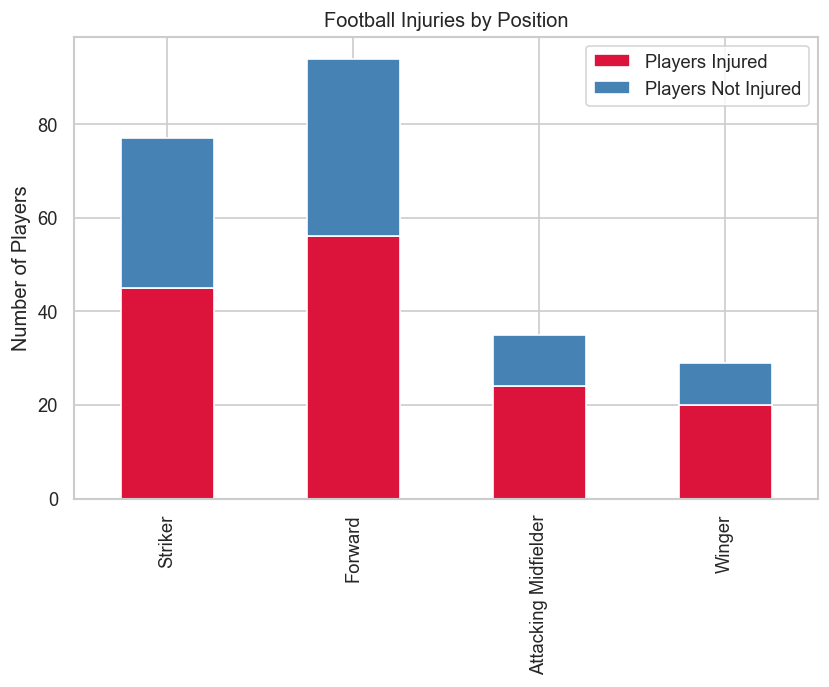

In [3]:
# Visualization: stacked bar chart
injury_table.drop("Total", axis=0).drop("Total", axis=1).T.plot(kind="bar", stacked=True, figsize=(8,5), color=["crimson","steelblue"])
plt.title("Football Injuries by Position")
plt.ylabel("Number of Players")
save_fig("p1_injury_stacked_bar.png")
plt.show()

In [4]:
# Calculate overall injury probability
total_injured_players = injury_table.loc["Players Injured", "Total"]
total_players = injury_table.loc["Total", "Total"]

# P(Injured) = Total Injured Players / Total Players
injury_probability = total_injured_players / total_players

print(f"P(Injured) = {total_injured_players} / {total_players} = {injury_probability:.3f}")
print(f"There is a {injury_probability:.1%} probability that a randomly chosen player from this team would suffer an injury.")

P(Injured) = 145 / 235 = 0.617
There is a 61.7% probability that a randomly chosen player from this team would suffer an injury.


In [5]:
# Calculate P(Forward or Winger)
total_forwards = injury_table.loc["Total", "Forward"]
total_wingers = injury_table.loc["Total", "Winger"]
total_players = injury_table.loc["Total", "Total"]

# P(Forward or Winger) = P(Forward) + P(Winger) - using addition rule for mutually exclusive events
p_forward = total_forwards / total_players
p_winger = total_wingers / total_players
p_forward_or_winger = p_forward + p_winger

print(f"P(Forward or Winger) = {total_forwards}/{total_players} + {total_wingers}/{total_players} = {total_forwards + total_wingers}/{total_players} = {p_forward_or_winger:.3f}")
print(f"There is a {p_forward_or_winger:.1%} probability that a player is either a forward or a winger.")

P(Forward or Winger) = 94/235 + 29/235 = 123/235 = 0.523
There is a 52.3% probability that a player is either a forward or a winger.


In [6]:
# Calculate P(Striker and Injury)
injured_strikers = injury_table.loc["Players Injured", "Striker"]
total_players = injury_table.loc["Total", "Total"]

# P(Striker and Injury) = Injured Strikers / Total Players
p_striker_and_injury = injured_strikers / total_players

print(f"P(Striker and Injury) = {injured_strikers}/{total_players} = {p_striker_and_injury:.3f}")
print(f"There is a {p_striker_and_injury:.1%} probability that a randomly selected player is an injured striker.")

P(Striker and Injury) = 45/235 = 0.191
There is a 19.1% probability that a randomly selected player is an injured striker.


In [7]:
# Calculate P(Striker | Injury)
injured_strikers = injury_table.loc["Players Injured", "Striker"]
total_injured_players = injury_table.loc["Players Injured", "Total"]

# P(Striker | Injury) = Number of Injured Strikers / Total Injured Players
p_striker_given_injury = injured_strikers / total_injured_players

print(f"P(Striker | Injury) = {injured_strikers}/{total_injured_players} = {p_striker_given_injury:.3f}")
print(f"If a player is injured, there is a {p_striker_given_injury:.1%} probability that they are a striker.")

P(Striker | Injury) = 45/145 = 0.310
If a player is injured, there is a 31.0% probability that they are a striker.


1. STACKED BAR CHART - Injured vs Not Injured per Position


  ✓ Saved: C:\Users\dsouh\OneDrive\Documents\PGP\Projectwork\2. Inferential Statistics - Multiple Case Studies\notebooks\..\images\p1_injury_annotated_bar.png


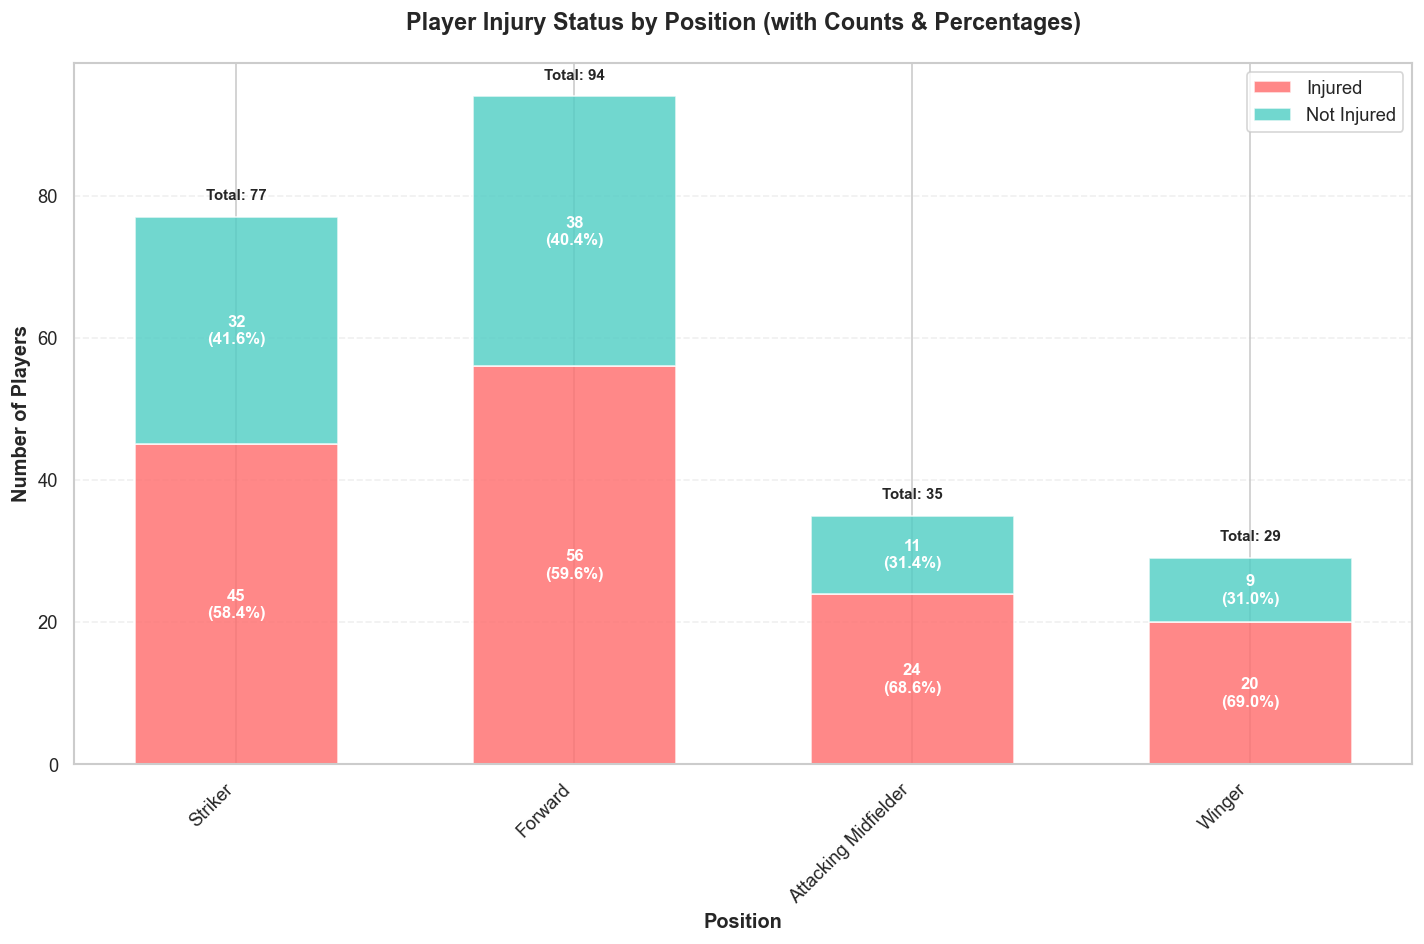

In [8]:
# STACKED BAR CHART with annotations
print("1. STACKED BAR CHART - Injured vs Not Injured per Position")
print("=" * 60)

# Prepare data (excluding 'Total' column)
positions = ['Striker', 'Forward', 'Attacking Midfielder', 'Winger']
injured = [45, 56, 24, 20]
not_injured = [32, 38, 11, 9]
totals = [77, 94, 35, 29]

# Create figure and axis
fig, ax = plt.subplots(figsize=(12, 8))

# Create stacked bar chart
bar_width = 0.6
x_pos = np.arange(len(positions))

# Create bars
bars1 = ax.bar(x_pos, injured, bar_width, label='Injured', color='#ff6b6b', alpha=0.8)
bars2 = ax.bar(x_pos, not_injured, bar_width, bottom=injured, label='Not Injured', color='#4ecdc4', alpha=0.8)

# Customize the plot
ax.set_xlabel('Position', fontsize=12, fontweight='bold')
ax.set_ylabel('Number of Players', fontsize=12, fontweight='bold')
ax.set_title('Player Injury Status by Position (with Counts & Percentages)', fontsize=14, fontweight='bold', pad=20)
ax.set_xticks(x_pos)
ax.set_xticklabels(positions, rotation=45, ha='right')
ax.legend(loc='upper right')

# Add count and percentage annotations
for i, (pos, inj, not_inj, total) in enumerate(zip(x_pos, injured, not_injured, totals)):
    # Injured section annotations
    inj_percentage = (inj / total) * 100
    ax.text(pos, inj/2, f'{inj}\n({inj_percentage:.1f}%)',
            ha='center', va='center', fontweight='bold', color='white', fontsize=10)

    # Not injured section annotations
    not_inj_percentage = (not_inj / total) * 100
    ax.text(pos, inj + not_inj/2, f'{not_inj}\n({not_inj_percentage:.1f}%)',
            ha='center', va='center', fontweight='bold', color='white', fontsize=10)

    # Total at the top
    ax.text(pos, total + 2, f'Total: {total}',
            ha='center', va='bottom', fontweight='bold', fontsize=9)

# Add grid for better readability
ax.grid(axis='y', alpha=0.3, linestyle='--')
ax.set_axisbelow(True)

plt.tight_layout()
save_fig("p1_injury_annotated_bar.png")
plt.show()


2. HEATMAP - Contingency Table Analysis


  ✓ Saved: C:\Users\dsouh\OneDrive\Documents\PGP\Projectwork\2. Inferential Statistics - Multiple Case Studies\notebooks\..\images\p1_contingency_heatmap.png


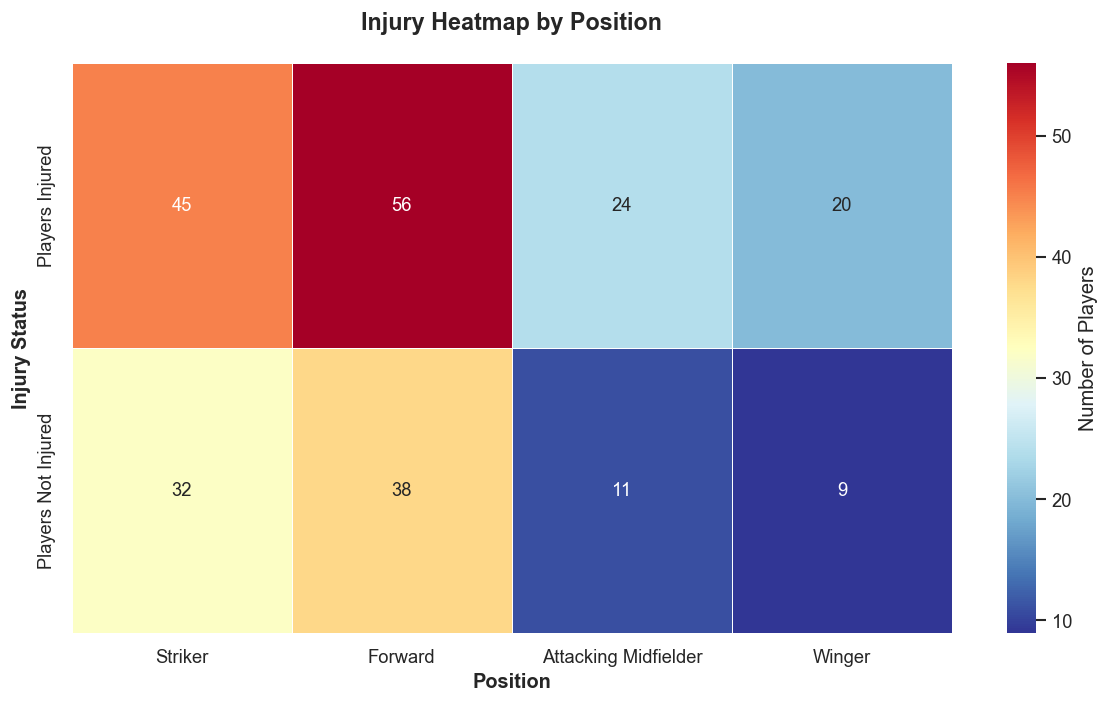

In [9]:
# HEATMAP of Contingency Table
print("\n2. HEATMAP - Contingency Table Analysis")
print("=" * 60)

# Prepare data for heatmap (exclude totals)
heatmap_data = injury_table.drop("Total", axis=0).drop("Total", axis=1)

# Create heatmap
plt.figure(figsize=(10, 6))
sns.heatmap(heatmap_data, annot=True, fmt='d', cmap='RdYlBu_r',
            cbar_kws={'label': 'Number of Players'},
            linewidths=0.5, linecolor='white')
plt.title('Injury Heatmap by Position', fontsize=14, fontweight='bold', pad=20)
plt.xlabel('Position', fontsize=12, fontweight='bold')
plt.ylabel('Injury Status', fontsize=12, fontweight='bold')
plt.tight_layout()
save_fig("p1_contingency_heatmap.png")
plt.show()

---

## Problem 2 — Cement Packaging (Gunny Bags)

**Business Context:** A cement company wants to understand the breaking strength distribution of their gunny bag packaging to minimize wastage and pilferage in the supply chain.

**Dataset:** No raw data provided — only population parameters.  
**See:** [`data/problem2_gunny_bags.txt`](../data/problem2_gunny_bags.txt)  
Distribution: **Normal(μ = 5 kg/cm², σ = 1.5 kg/cm²)**

**Questions:**
- **2.1** P(breaking strength < 3.17 kg/cm²)
- **2.2** P(breaking strength ≥ 3.6 kg/cm²)
- **2.3** P(5 ≤ breaking strength ≤ 5.5 kg/cm²)
- **2.4** P(breaking strength NOT between 3 and 7.5 kg/cm²)

Now, let's look into Problem Statement 2.

In [10]:
# ================================
# Problem 2 — Gunny Bag Strength
# ================================

mu, sigma = 5, 1.5

# Proportions
p1 = norm.cdf(3.17, mu, sigma)                              # P(X < 3.17)
p2 = 1 - norm.cdf(3.6, mu, sigma)                           # P(X ≥ 3.6)
p3 = norm.cdf(5.5, mu, sigma) - norm.cdf(5, mu, sigma)      # P(5 ≤ X ≤ 5.5)
p4 = 1 - (norm.cdf(7.5, mu, sigma) - norm.cdf(3, mu, sigma)) # P(X not in [3,7.5])

# Results table
prop_table = pd.DataFrame({
    "Probability": [p1, p2, p3, p4]
}, index=[
    "P(X < 3.17)",
    "P(X ≥ 3.6)",
    "P(5 ≤ X ≤ 5.5)",
    "P(X ∉ [3, 7.5])"
])

display(prop_table)

,Probability
P(X < 3.17),0.111232
P(X ≥ 3.6),0.824676
P(5 ≤ X ≤ 5.5),0.130559
"P(X ∉ [3, 7.5])",0.139002


  ✓ Saved: C:\Users\dsouh\OneDrive\Documents\PGP\Projectwork\2. Inferential Statistics - Multiple Case Studies\notebooks\..\images\p2_normal_dist_2_1.png


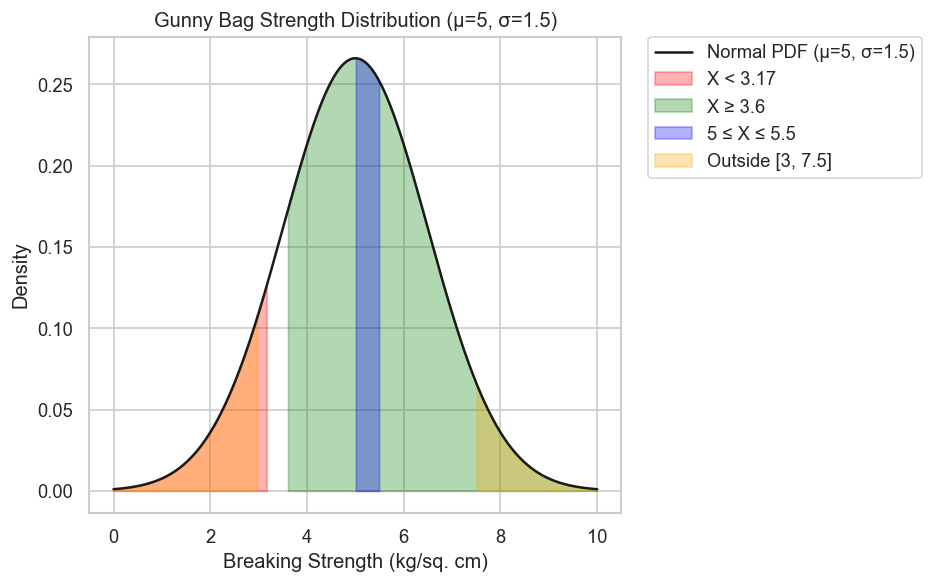

In [11]:
# Visualization: Normal PDF with shaded regions
x = np.linspace(0, 10, 500)
y = norm.pdf(x, mu, sigma)

plt.figure(figsize=(8,5))
plt.plot(x, y, 'k', label="Normal PDF (μ=5, σ=1.5)")

plt.fill_between(x, y, where=(x < 3.17), color="red", alpha=0.3, label="X < 3.17")
plt.fill_between(x, y, where=(x >= 3.6), color="green", alpha=0.3, label="X ≥ 3.6")
plt.fill_between(x, y, where=(x >= 5) & (x <= 5.5), color="blue", alpha=0.3, label="5 ≤ X ≤ 5.5")
plt.fill_between(x, y, where=(x < 3) | (x > 7.5), color="orange", alpha=0.3, label="Outside [3, 7.5]")

plt.title("Gunny Bag Strength Distribution (μ=5, σ=1.5)")
plt.xlabel("Breaking Strength (kg/sq. cm)")
plt.ylabel("Density")

# Place legend outside the plot
plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left", borderaxespad=0.)

plt.tight_layout()
save_fig("p2_normal_dist_2_1.png")
plt.show()

In [12]:
# Given parameters
x_value = 3.17

print("Z-SCORE CALCULATION FOR P(X < 3.17)")
print("=" * 50)

# Calculate Z-score
z_score = (x_value - mu) / sigma
print(f"Z = (X - μ) / σ")
print(f"Z = ({x_value} - {mu}) / {sigma}")
print(f"Z = {z_score:.2f}")

# Calculate probability using CDF
probability = norm.cdf(x_value, mu, sigma)
z_probability = norm.cdf(z_score)  # Using standard normal

print(f"\nCDF CALCULATION:")
print(f"P(X < {x_value}) = P(Z < {z_score:.2f}) = {probability:.4f}")
print(f"Percentage: {probability * 100:.2f}%")

print(f"\nFINDING:")
print(f"Approximately {probability * 100:.2f}% of the gunny bags have a breakingstrength less than {x_value} kg/sq cm.")

Z-SCORE CALCULATION FOR P(X < 3.17)
Z = (X - μ) / σ
Z = (3.17 - 5) / 1.5
Z = -1.22

CDF CALCULATION:
P(X < 3.17) = P(Z < -1.22) = 0.1112
Percentage: 11.12%

FINDING:
Approximately 11.12% of the gunny bags have a breakingstrength less than 3.17 kg/sq cm.


  ✓ Saved: C:\Users\dsouh\OneDrive\Documents\PGP\Projectwork\2. Inferential Statistics - Multiple Case Studies\notebooks\..\images\p2_normal_dist_2_2.png


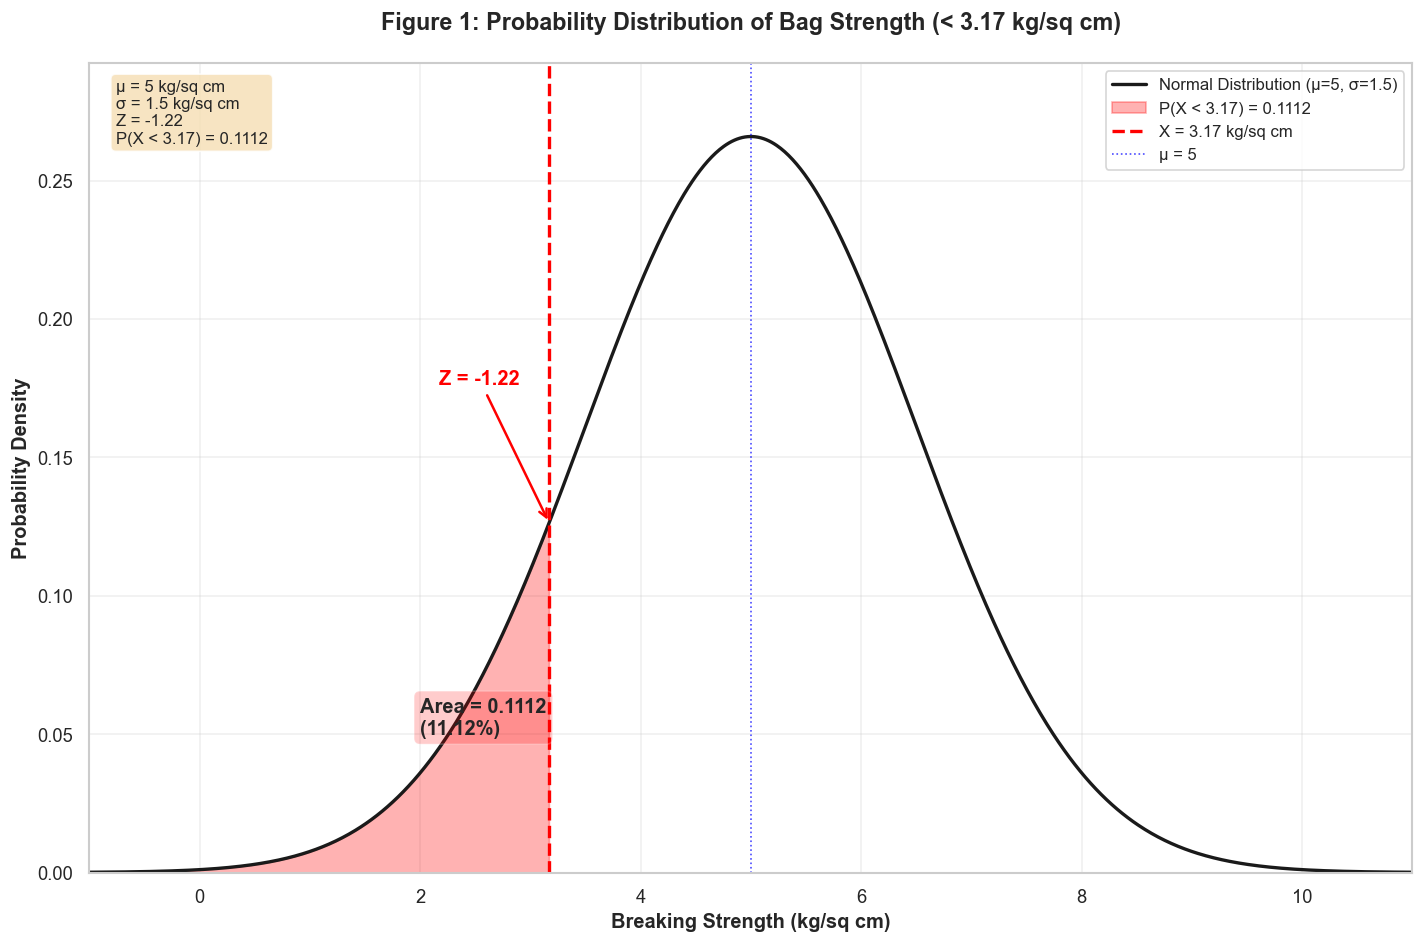

In [13]:
# ================================
# VISUALIZATION
# ================================

# Create the normal distribution curve
x = np.linspace(mu - 4*sigma, mu + 4*sigma, 1000)
y = norm.pdf(x, mu, sigma)

# Create figure
plt.figure(figsize=(12, 8))

# Plot the normal curve
plt.plot(x, y, 'k-', linewidth=2, label=f'Normal Distribution (μ={mu}, σ={sigma})')

# Shade the area for P(X < 3.17)
x_fill = x[x <= x_value]
y_fill = norm.pdf(x_fill, mu, sigma)
plt.fill_between(x_fill, y_fill, alpha=0.3, color='red',
                 label=f'P(X < {x_value}) = {probability:.4f}')

# Add vertical line at x = 3.17
plt.axvline(x=x_value, color='red', linestyle='--', linewidth=2,
            label=f'X = {x_value} kg/sq cm')

# Add mean line
plt.axvline(x=mu, color='blue', linestyle=':', linewidth=1, alpha=0.7,
            label=f'μ = {mu}')

# Annotations
plt.annotate(f'Z = {z_score:.2f}',
             xy=(x_value, norm.pdf(x_value, mu, sigma)),
             xytext=(x_value - 1, norm.pdf(x_value, mu, sigma) + 0.05),
             arrowprops=dict(arrowstyle='->', color='red', lw=1.5),
             fontsize=12, fontweight='bold', color='red')

plt.annotate(f'Area = {probability:.4f}\n({probability*100:.2f}%)',
             xy=(2, 0.05), fontsize=12, fontweight='bold',
             bbox=dict(boxstyle="round,pad=0.3", facecolor="red", alpha=0.2))

# Customize plot
plt.title('Figure 1: Probability Distribution of Bag Strength (< 3.17 kg/sq cm)',
          fontsize=14, fontweight='bold', pad=20)
plt.xlabel('Breaking Strength (kg/sq cm)', fontsize=12, fontweight='bold')
plt.ylabel('Probability Density', fontsize=12, fontweight='bold')
plt.grid(True, alpha=0.3)
plt.legend(loc='upper right', fontsize=10)

# Set axis limits for better visualization
plt.xlim(mu - 4*sigma, mu + 4*sigma)
plt.ylim(0, max(y) * 1.1)

# Add text box with key statistics
textstr = f'μ = {mu} kg/sq cm\nσ = {sigma} kg/sq cm\nZ = {z_score:.2f}\nP(X < {x_value}) = {probability:.4f}'
props = dict(boxstyle='round', facecolor='wheat', alpha=0.8)
plt.text(0.02, 0.98, textstr, transform=plt.gca().transAxes, fontsize=10,
         verticalalignment='top', bbox=props)

plt.tight_layout()
save_fig("p2_normal_dist_2_2.png")
plt.show()

In [14]:
# ================================
# DETAILED CDF CALCULATION OUTPUT
# ================================

print("\n" + "="*60)
print("DETAILED CDF CALCULATION AND NUMERIC OUTPUT")
print("="*60)

# Create summary table
calculation_data = {
    'Parameter': ['Mean (μ)', 'Standard Deviation (σ)', 'X Value', 'Z-Score', 'CDF Value', 'Probability', 'Percentage'],
    'Value': [mu, sigma, x_value, z_score, probability, probability, f"{probability*100:.2f}%"],
    'Formula/Description': [
        'Given parameter',
        'Given parameter',
        'Threshold value',
        '(X - μ) / σ',
        'P(X < 3.17)',
        'Area under curve',
        'Percentage of bags below threshold'
    ]
}

calc_table = pd.DataFrame(calculation_data)
print("\nCalculation Summary:")
display(calc_table)

# Additional quality implications
print(f"\nQUALITY IMPLICATIONS:")
print(f"• Out of 1000 bags, approximately {int(probability * 1000)} bags would fail")
print(f"• This represents a {probability*100:.2f}% failure rate for quality standards")
print(f"• Economic impact: High wastage and potential customer dissatisfaction")
print(f"• Recommendation: Review manufacturing process to reduce variability")

# Standard normal equivalent
print(f"\nSTANDARD NORMAL EQUIVALENT:")
print(f"P(Z < {z_score:.2f}) = {z_probability:.4f}")
print(f"This confirms our calculation using the standardized normal distribution.")


DETAILED CDF CALCULATION AND NUMERIC OUTPUT

Calculation Summary:


,Parameter,Value,Formula/Description
0,Mean (μ),5,Given parameter
1,Standard Deviation (σ),1.5,Given parameter
2,X Value,3.17,Threshold value
3,Z-Score,-1.22,(X - μ) / σ
4,CDF Value,0.111232,P(X < 3.17)
5,Probability,0.111232,Area under curve
6,Percentage,11.12%,Percentage of bags below threshold



QUALITY IMPLICATIONS:
• Out of 1000 bags, approximately 111 bags would fail
• This represents a 11.12% failure rate for quality standards
• Economic impact: High wastage and potential customer dissatisfaction
• Recommendation: Review manufacturing process to reduce variability

STANDARD NORMAL EQUIVALENT:
P(Z < -1.22) = 0.1112
This confirms our calculation using the standardized normal distribution.


In [15]:
# Given parameters
x_value = 3.6

print("Z-SCORE CALCULATION FOR P(X ≥ 3.6)")
print("=" * 50)

# Calculate Z-score
z_score = (x_value - mu) / sigma
print(f"Z = (X - μ) / σ")
print(f"Z = ({x_value} - {mu}) / {sigma}")
print(f"Z = {z_score:.3f}")

# Calculate probabilities
prob_less_than = norm.cdf(x_value, mu, sigma)  # P(X < 3.6)
probability = 1 - prob_less_than  # P(X ≥ 3.6)

# Using standard normal
z_prob_less_than = norm.cdf(z_score)  # P(Z < -0.933)
z_probability = 1 - z_prob_less_than  # P(Z ≥ -0.933)

print(f"\nCDF CALCULATION:")
print(f"P(X < {x_value}) = P(Z < {z_score:.3f}) = {prob_less_than:.4f}")
print(f"P(X ≥ {x_value}) = 1 - P(X < {x_value})")
print(f"P(X ≥ {x_value}) = 1 - {prob_less_than:.4f} = {probability:.4f}")
print(f"Percentage: {probability * 100:.2f}%")

print(f"\nFINDING:")
print(f"Approximately {probability * 100:.2f}% of gunny bags have a breaking strength of at least {x_value} kg/sq cm.")

Z-SCORE CALCULATION FOR P(X ≥ 3.6)
Z = (X - μ) / σ
Z = (3.6 - 5) / 1.5
Z = -0.933

CDF CALCULATION:
P(X < 3.6) = P(Z < -0.933) = 0.1753
P(X ≥ 3.6) = 1 - P(X < 3.6)
P(X ≥ 3.6) = 1 - 0.1753 = 0.8247
Percentage: 82.47%

FINDING:
Approximately 82.47% of gunny bags have a breaking strength of at least 3.6 kg/sq cm.


  ✓ Saved: C:\Users\dsouh\OneDrive\Documents\PGP\Projectwork\2. Inferential Statistics - Multiple Case Studies\notebooks\..\images\p2_normal_dist_2_3.png


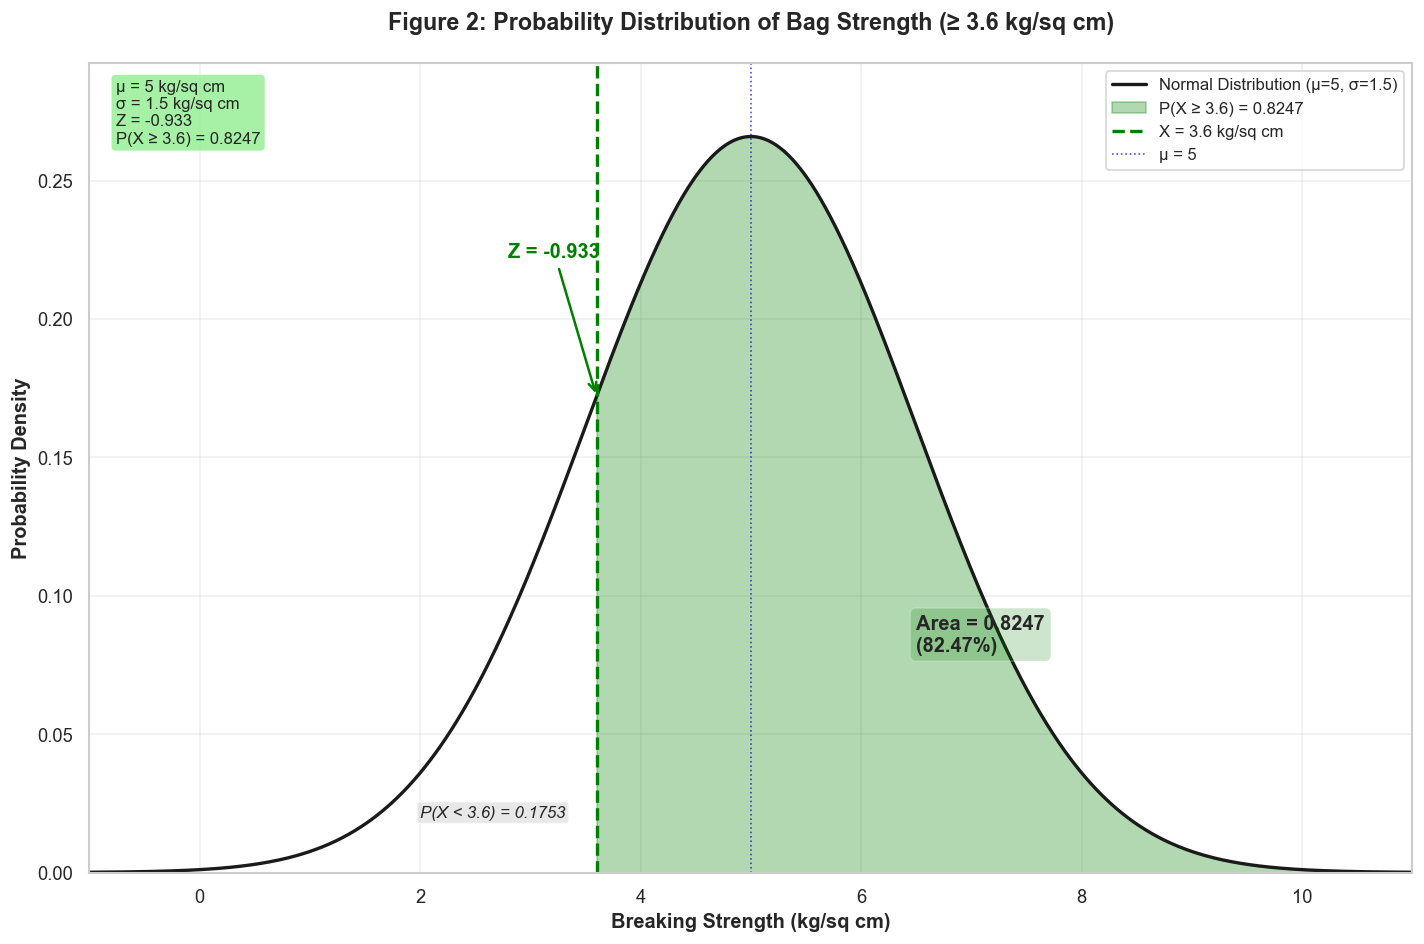

In [16]:
# Create the normal distribution curve
x = np.linspace(mu - 4*sigma, mu + 4*sigma, 1000)
y = norm.pdf(x, mu, sigma)

# Create figure
plt.figure(figsize=(12, 8))

# Plot the normal curve
plt.plot(x, y, 'k-', linewidth=2, label=f'Normal Distribution (μ={mu}, σ={sigma})')

# Shade the area for P(X ≥ 3.6)
x_fill = x[x >= x_value]
y_fill = norm.pdf(x_fill, mu, sigma)
plt.fill_between(x_fill, y_fill, alpha=0.3, color='green',
                 label=f'P(X ≥ {x_value}) = {probability:.4f}')

# Add vertical line at x = 3.6
plt.axvline(x=x_value, color='green', linestyle='--', linewidth=2,
            label=f'X = {x_value} kg/sq cm')

# Add mean line
plt.axvline(x=mu, color='blue', linestyle=':', linewidth=1, alpha=0.7,
            label=f'μ = {mu}')

# Annotations
plt.annotate(f'Z = {z_score:.3f}',
             xy=(x_value, norm.pdf(x_value, mu, sigma)),
             xytext=(x_value - 0.8, norm.pdf(x_value, mu, sigma) + 0.05),
             arrowprops=dict(arrowstyle='->', color='green', lw=1.5),
             fontsize=12, fontweight='bold', color='green')

plt.annotate(f'Area = {probability:.4f}\n({probability*100:.2f}%)',
             xy=(6.5, 0.08), fontsize=12, fontweight='bold',
             bbox=dict(boxstyle="round,pad=0.3", facecolor="green", alpha=0.2))

# Add complement area annotation
plt.annotate(f'P(X < {x_value}) = {prob_less_than:.4f}',
             xy=(2, 0.02), fontsize=10, style='italic',
             bbox=dict(boxstyle="round,pad=0.2", facecolor="lightgray", alpha=0.5))

# Customize plot
plt.title('Figure 2: Probability Distribution of Bag Strength (≥ 3.6 kg/sq cm)',
          fontsize=14, fontweight='bold', pad=20)
plt.xlabel('Breaking Strength (kg/sq cm)', fontsize=12, fontweight='bold')
plt.ylabel('Probability Density', fontsize=12, fontweight='bold')
plt.grid(True, alpha=0.3)
plt.legend(loc='upper right', fontsize=10)

# Set axis limits for better visualization
plt.xlim(mu - 4*sigma, mu + 4*sigma)
plt.ylim(0, max(y) * 1.1)

# Add text box with key statistics
textstr = f'μ = {mu} kg/sq cm\nσ = {sigma} kg/sq cm\nZ = {z_score:.3f}\nP(X ≥ {x_value}) = {probability:.4f}'
props = dict(boxstyle='round', facecolor='lightgreen', alpha=0.8)
plt.text(0.02, 0.98, textstr, transform=plt.gca().transAxes, fontsize=10,
         verticalalignment='top', bbox=props)

plt.tight_layout()
save_fig("p2_normal_dist_2_3.png")
plt.show()

In [17]:
print(f"1. Calculate Z-score:")
print(f"   Z = (X - μ) / σ = ({x_value} - {mu}) / {sigma} = {z_score:.3f}")
print(f"")
print(f"2. Find P(Z < {z_score:.3f}):")
print(f"   P(Z < {z_score:.3f}) = {prob_less_than:.4f}")
print(f"")
print(f"3. Calculate P(Z ≥ {z_score:.3f}):")
print(f"   P(Z ≥ {z_score:.3f}) = 1 - P(Z < {z_score:.3f})")
print(f"   P(Z ≥ {z_score:.3f}) = 1 - {prob_less_than:.4f} = {probability:.4f}")

# Create detailed summary table
calculation_data = {
    'Step': [
        'Given Parameters',
        'Threshold Value',
        'Z-Score Calculation',
        'P(X < 3.6)',
        'P(X ≥ 3.6)',
        'Final Probability',
        'Percentage'
    ],
    'Calculation': [
        'μ = 5, σ = 1.5',
        'X = 3.6',
        f'Z = ({x_value} - {mu}) / {sigma}',
        f'P(Z < {z_score:.3f})',
        f'1 - P(Z < {z_score:.3f})',
        f'{probability:.4f}',
        f'{probability*100:.2f}%'
    ],
    'Result': [
        'Parameters set',
        f'{x_value} kg/sq cm',
        f'{z_score:.3f}',
        f'{prob_less_than:.4f}',
        f'{probability:.4f}',
        f'{probability:.4f}',
        f'{probability*100:.2f}%'
    ]
}

calc_table = pd.DataFrame(calculation_data)
print(f"\nDetailed Calculation Table:")
display(calc_table)

1. Calculate Z-score:
   Z = (X - μ) / σ = (3.6 - 5) / 1.5 = -0.933

2. Find P(Z < -0.933):
   P(Z < -0.933) = 0.1753

3. Calculate P(Z ≥ -0.933):
   P(Z ≥ -0.933) = 1 - P(Z < -0.933)
   P(Z ≥ -0.933) = 1 - 0.1753 = 0.8247

Detailed Calculation Table:


,Step,Calculation,Result
0,Given Parameters,"μ = 5, σ = 1.5",Parameters set
1,Threshold Value,X = 3.6,3.6 kg/sq cm
2,Z-Score Calculation,Z = (3.6 - 5) / 1.5,-0.933
3,P(X < 3.6),P(Z < -0.933),0.1753
4,P(X ≥ 3.6),1 - P(Z < -0.933),0.8247
5,Final Probability,0.8247,0.8247
6,Percentage,82.47%,82.47%


In [18]:
# ================================
# RELIABILITY ANALYSIS
# ================================

print(f"\nRELIABILITY ANALYSIS:")
print(f"• {probability*100:.2f}% of bags meet minimum strength requirement of {x_value} kg/sq cm")
print(f"• Only {prob_less_than*100:.2f}% of bags fall below the threshold")
print(f"• High reliability indicates good manufacturing quality control")

print(f"\nBUSINESS IMPLICATIONS:")
print(f"• Quality Assurance: {probability*100:.2f}% pass rate is excellent")
print(f"• Customer Confidence: High strength reliability")
print(f"• Manufacturing: Process is well-controlled")
print(f"• Risk Assessment: Low probability of strength failure")

# Comparison with previous analysis
print(f"\nCOMPARISON WITH PREVIOUS THRESHOLD:")
print(f"• P(X < 3.17) = 11.12% (failure rate)")
print(f"• P(X ≥ 3.6) = {probability*100:.2f}% (success rate)")
print(f"• The 3.6 kg/sq cm threshold shows much better reliability")

# Standard normal verification
print(f"\nSTANDARD NORMAL VERIFICATION:")
print(f"Using standard normal table: P(Z ≥ {z_score:.3f}) = {z_probability:.4f}")
print(f"This confirms our calculation: {probability:.4f} ✓")


RELIABILITY ANALYSIS:
• 82.47% of bags meet minimum strength requirement of 3.6 kg/sq cm
• Only 17.53% of bags fall below the threshold
• High reliability indicates good manufacturing quality control

BUSINESS IMPLICATIONS:
• Quality Assurance: 82.47% pass rate is excellent
• Customer Confidence: High strength reliability
• Manufacturing: Process is well-controlled
• Risk Assessment: Low probability of strength failure

COMPARISON WITH PREVIOUS THRESHOLD:
• P(X < 3.17) = 11.12% (failure rate)
• P(X ≥ 3.6) = 82.47% (success rate)
• The 3.6 kg/sq cm threshold shows much better reliability

STANDARD NORMAL VERIFICATION:
Using standard normal table: P(Z ≥ -0.933) = 0.8247
This confirms our calculation: 0.8247 ✓


In [19]:
# Z-Score Analysis for P(5 ≤ X ≤ 5.5)

# Given parameters
x1, x2 = 5, 5.5

print("Z-SCORE CALCULATION FOR P(5 ≤ X ≤ 5.5)")
print("=" * 50)

# Calculate Z-scores
z1 = (x1 - mu) / sigma
z2 = (x2 - mu) / sigma

print(f"Z₁ = (X₁ - μ) / σ")
print(f"Z₁ = ({x1} - {mu}) / {sigma} = {z1:.3f}")
print(f"")
print(f"Z₂ = (X₂ - μ) / σ")
print(f"Z₂ = ({x2} - {mu}) / {sigma} = {z2:.3f}")

# Calculate probabilities
prob_z1 = norm.cdf(z1)  # P(Z < 0)
prob_z2 = norm.cdf(z2)  # P(Z < 0.333)
probability = prob_z2 - prob_z1  # P(0 < Z < 0.333)

# Direct calculation using original distribution
prob_x1 = norm.cdf(x1, mu, sigma)  # P(X < 5)
prob_x2 = norm.cdf(x2, mu, sigma)  # P(X < 5.5)
probability_direct = prob_x2 - prob_x1  # P(5 ≤ X ≤ 5.5)

print(f"\nSTANDARD NORMAL CALCULATION:")
print(f"P(0 < Z < 0.333) = P(Z < 0.333) - P(Z < 0)")
print(f"P(0 < Z < 0.333) = {prob_z2:.4f} - {prob_z1:.4f} = {probability:.4f}")
print(f"")
print(f"DIRECT CALCULATION:")
print(f"P(5 ≤ X ≤ 5.5) = P(X ≤ 5.5) - P(X < 5)")
print(f"P(5 ≤ X ≤ 5.5) = {prob_x2:.4f} - {prob_x1:.4f} = {probability_direct:.4f}")
print(f"")
print(f"Percentage: {probability * 100:.2f}%")

print(f"\nFINDING:")
print(f"Approximately {probability * 100:.2f}% of bags have a breaking strength between {x1} and {x2} kg/sq cm.")

Z-SCORE CALCULATION FOR P(5 ≤ X ≤ 5.5)
Z₁ = (X₁ - μ) / σ
Z₁ = (5 - 5) / 1.5 = 0.000

Z₂ = (X₂ - μ) / σ
Z₂ = (5.5 - 5) / 1.5 = 0.333

STANDARD NORMAL CALCULATION:
P(0 < Z < 0.333) = P(Z < 0.333) - P(Z < 0)
P(0 < Z < 0.333) = 0.6306 - 0.5000 = 0.1306

DIRECT CALCULATION:
P(5 ≤ X ≤ 5.5) = P(X ≤ 5.5) - P(X < 5)
P(5 ≤ X ≤ 5.5) = 0.6306 - 0.5000 = 0.1306

Percentage: 13.06%

FINDING:
Approximately 13.06% of bags have a breaking strength between 5 and 5.5 kg/sq cm.


C:\Users\dsouh\AppData\Local\Temp\ipykernel_37928\2701534562.py:66: UserWarning: Glyph 8321 (\N{SUBSCRIPT ONE}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\dsouh\AppData\Local\Temp\ipykernel_37928\2701534562.py:66: UserWarning: Glyph 8322 (\N{SUBSCRIPT TWO}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\dsouh\AppData\Local\Temp\ipykernel_37928\3596546718.py:28: UserWarning: Glyph 8321 (\N{SUBSCRIPT ONE}) missing from font(s) Arial.
  plt.savefig(path, bbox_inches='tight', dpi=150)
C:\Users\dsouh\AppData\Local\Temp\ipykernel_37928\3596546718.py:28: UserWarning: Glyph 8322 (\N{SUBSCRIPT TWO}) missing from font(s) Arial.
  plt.savefig(path, bbox_inches='tight', dpi=150)


  ✓ Saved: C:\Users\dsouh\OneDrive\Documents\PGP\Projectwork\2. Inferential Statistics - Multiple Case Studies\notebooks\..\images\p2_normal_dist_2_4.png


C:\Users\dsouh\anaconda3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 8321 (\N{SUBSCRIPT ONE}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\dsouh\anaconda3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 8322 (\N{SUBSCRIPT TWO}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


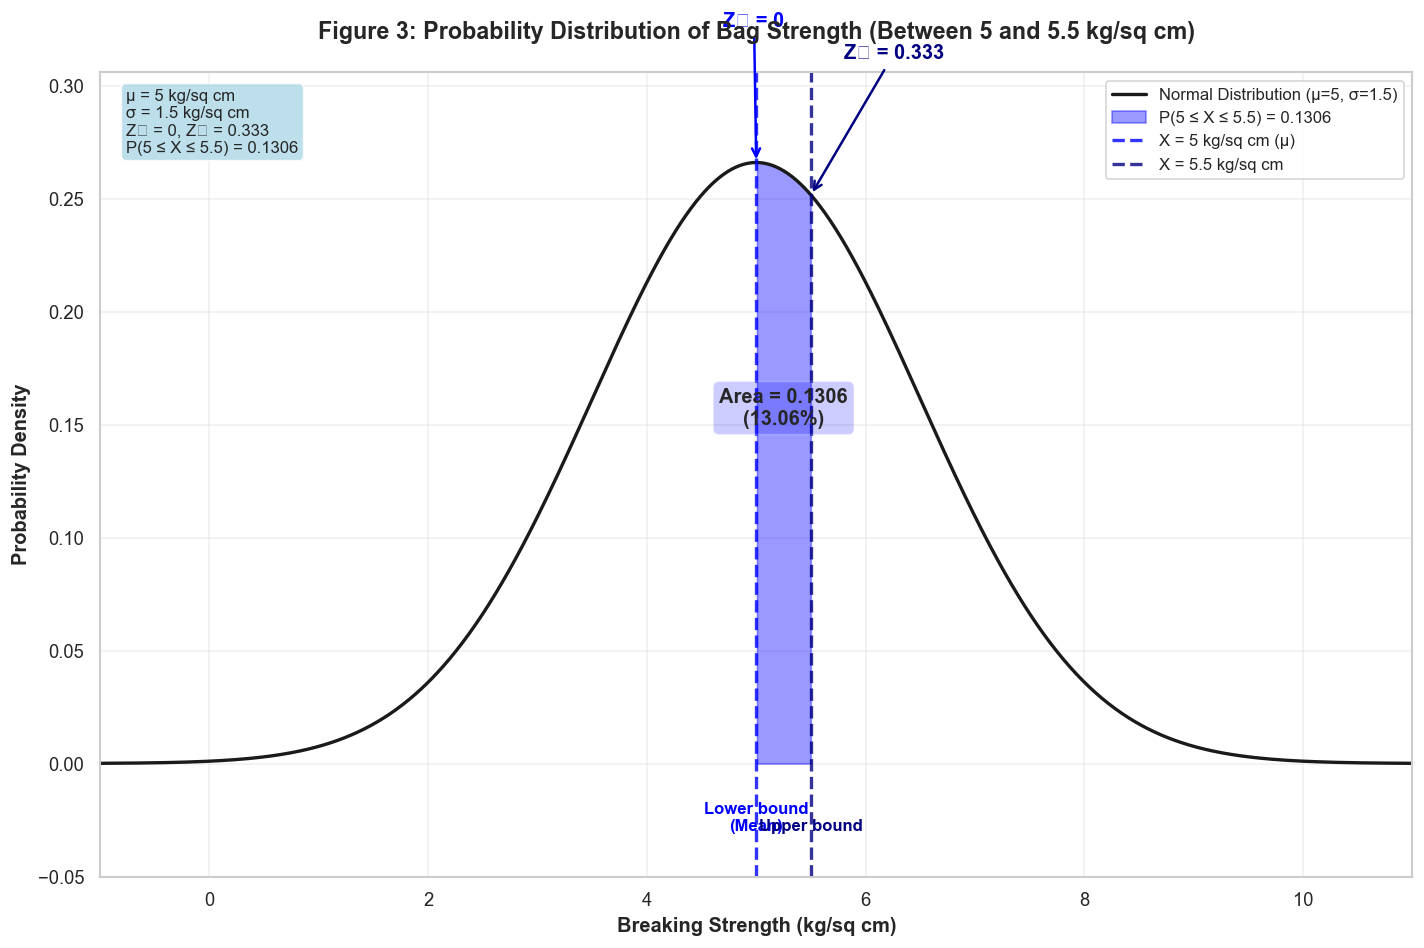

In [20]:
# Create the normal distribution curve
x = np.linspace(mu - 4*sigma, mu + 4*sigma, 1000)
y = norm.pdf(x, mu, sigma)

# Create figure
plt.figure(figsize=(12, 8))

# Plot the normal curve
plt.plot(x, y, 'k-', linewidth=2, label=f'Normal Distribution (μ={mu}, σ={sigma})')

# Shade the area for P(5 ≤ X ≤ 5.5)
x_fill = x[(x >= x1) & (x <= x2)]
y_fill = norm.pdf(x_fill, mu, sigma)
plt.fill_between(x_fill, y_fill, alpha=0.4, color='blue',
                 label=f'P({x1} ≤ X ≤ {x2}) = {probability:.4f}')

# Add vertical lines at x = 5 and x = 5.5
plt.axvline(x=x1, color='blue', linestyle='--', linewidth=2, alpha=0.8,
            label=f'X = {x1} kg/sq cm (μ)')
plt.axvline(x=x2, color='navy', linestyle='--', linewidth=2, alpha=0.8,
            label=f'X = {x2} kg/sq cm')

# Annotations for Z-scores
plt.annotate(f'Z₁ = {z1:.0f}',
             xy=(x1, norm.pdf(x1, mu, sigma)),
             xytext=(x1 - 0.3, norm.pdf(x1, mu, sigma) + 0.06),
             arrowprops=dict(arrowstyle='->', color='blue', lw=1.5),
             fontsize=12, fontweight='bold', color='blue')

plt.annotate(f'Z₂ = {z2:.3f}',
             xy=(x2, norm.pdf(x2, mu, sigma)),
             xytext=(x2 + 0.3, norm.pdf(x2, mu, sigma) + 0.06),
             arrowprops=dict(arrowstyle='->', color='navy', lw=1.5),
             fontsize=12, fontweight='bold', color='navy')

# Central area annotation
plt.annotate(f'Area = {probability:.4f}\n({probability*100:.2f}%)',
             xy=(5.25, 0.15), fontsize=12, fontweight='bold',
             bbox=dict(boxstyle="round,pad=0.3", facecolor="blue", alpha=0.2),
             ha='center')

# Add boundary annotations
plt.annotate(f'Lower bound\n(Mean)', xy=(x1, -0.01), xytext=(x1, -0.03),
             fontsize=10, ha='center', color='blue', fontweight='bold')
plt.annotate(f'Upper bound', xy=(x2, -0.01), xytext=(x2, -0.03),
             fontsize=10, ha='center', color='navy', fontweight='bold')

# Customize plot
plt.title('Figure 3: Probability Distribution of Bag Strength (Between 5 and 5.5 kg/sq cm)',
          fontsize=14, fontweight='bold', pad=20)
plt.xlabel('Breaking Strength (kg/sq cm)', fontsize=12, fontweight='bold')
plt.ylabel('Probability Density', fontsize=12, fontweight='bold')
plt.grid(True, alpha=0.3)
plt.legend(loc='upper right', fontsize=10)

# Set axis limits for better visualization
plt.xlim(mu - 4*sigma, mu + 4*sigma)
plt.ylim(-0.05, max(y) * 1.15)

# Add text box with key statistics
textstr = f'μ = {mu} kg/sq cm\nσ = {sigma} kg/sq cm\nZ₁ = {z1:.0f}, Z₂ = {z2:.3f}\nP({x1} ≤ X ≤ {x2}) = {probability:.4f}'
props = dict(boxstyle='round', facecolor='lightblue', alpha=0.8)
plt.text(0.02, 0.98, textstr, transform=plt.gca().transAxes, fontsize=10,
         verticalalignment='top', bbox=props)

plt.tight_layout()
save_fig("p2_normal_dist_2_4.png")
plt.show()

In [21]:
# Step-by-step calculation display
print("STEP-BY-STEP CALCULATION:")
print(f"1. Calculate Z-scores:")
print(f"   Z₁ = (X₁ - μ) / σ = ({x1} - {mu}) / {sigma} = {z1:.3f}")
print(f"   Z₂ = (X₂ - μ) / σ = ({x2} - {mu}) / {sigma} = {z2:.3f}")
print(f"")
print(f"2. Find individual probabilities:")
print(f"   P(Z < {z1:.0f}) = P(Z < 0) = {prob_z1:.4f}")
print(f"   P(Z < {z2:.3f}) = {prob_z2:.4f}")
print(f"")
print(f"3. Calculate interval probability:")
print(f"   P(0 < Z < 0.333) = P(Z < 0.333) - P(Z < 0)")
print(f"   P(0 < Z < 0.333) = {prob_z2:.4f} - {prob_z1:.4f} = {probability:.4f}")

# Create comprehensive summary table
calculation_data = {
    'Parameter': [
        'Lower Bound (X₁)',
        'Upper Bound (X₂)',
        'Z₁ Score',
        'Z₂ Score',
        'P(Z < Z₁)',
        'P(Z < Z₂)',
        'P(Z₁ ≤ Z ≤ Z₂)',
        'Final Probability',
        'Percentage'
    ],
    'Value': [
        f'{x1}',
        f'{x2}',
        f'{z1:.3f}',
        f'{z2:.3f}',
        f'{prob_z1:.4f}',
        f'{prob_z2:.4f}',
        f'{probability:.4f}',
        f'{probability:.4f}',
        f'{probability*100:.2f}%'
    ],
    'Description': [
        'Mean value (μ)',
        '0.5 kg/sq cm above mean',
        'Standardized lower bound',
        'Standardized upper bound',
        'CDF at lower bound',
        'CDF at upper bound',
        'Interval probability',
        'P(5 ≤ X ≤ 5.5)',
        'Percentage of bags in range'
    ]
}

calc_table = pd.DataFrame(calculation_data)
print(f"\nComprehensive Calculation Table:")
display(calc_table)

STEP-BY-STEP CALCULATION:
1. Calculate Z-scores:
   Z₁ = (X₁ - μ) / σ = (5 - 5) / 1.5 = 0.000
   Z₂ = (X₂ - μ) / σ = (5.5 - 5) / 1.5 = 0.333

2. Find individual probabilities:
   P(Z < 0) = P(Z < 0) = 0.5000
   P(Z < 0.333) = 0.6306

3. Calculate interval probability:
   P(0 < Z < 0.333) = P(Z < 0.333) - P(Z < 0)
   P(0 < Z < 0.333) = 0.6306 - 0.5000 = 0.1306

Comprehensive Calculation Table:


,Parameter,Value,Description
0,Lower Bound (X₁),5,Mean value (μ)
1,Upper Bound (X₂),5.5,0.5 kg/sq cm above mean
2,Z₁ Score,0.000,Standardized lower bound
3,Z₂ Score,0.333,Standardized upper bound
4,P(Z < Z₁),0.5000,CDF at lower bound
5,P(Z < Z₂),0.6306,CDF at upper bound
6,P(Z₁ ≤ Z ≤ Z₂),0.1306,Interval probability
7,Final Probability,0.1306,P(5 ≤ X ≤ 5.5)
8,Percentage,13.06%,Percentage of bags in range


In [22]:
print(f"\nCONCENTRATION AROUND THE MEAN ANALYSIS:")
print(f"• {probability*100:.2f}% of bags fall within 0.5 kg/sq cm above the mean")
print(f"• This represents the density of the distribution near the central value")
print(f"• The interval [{x1}, {x2}] shows moderate concentration around μ = {mu}")

print(f"\nSTATISTICAL INSIGHTS:")
print(f"• Mean (μ = {mu}) is the lower boundary of this interval")
print(f"• Upper bound is μ + 0.33σ (approximately 1/3 standard deviation)")
print(f"• This interval captures {probability*100:.2f}% of the right half of the distribution")

print(f"\nCOMPARISON WITH NORMAL DISTRIBUTION PROPERTIES:")
print(f"• About 34% of data falls between μ and μ + σ in a normal distribution")
print(f"• Our interval (μ to μ + 0.33σ) captures {probability*100:.2f}% of total data")
print(f"• This is roughly {(probability/0.34)*100:.1f}% of the expected μ to μ+σ range")

# Quality control implications
print(f"\nQUALITY CONTROL IMPLICATIONS:")
print(f"• Bags in this range are at or slightly above specification")
print(f"• {probability*100:.2f}% concentration indicates good process control")
print(f"• Consistent performance around the target strength value")

# Verification using symmetry
prob_symmetric = norm.cdf(x1 - (x2-x1), mu, sigma)  # P(X < 4.5)
symmetric_interval = prob_x1 - prob_symmetric  # P(4.5 ≤ X < 5)
print(f"\nSYMMETRIC VERIFICATION:")
print(f"P(4.5 ≤ X < 5.0) = {symmetric_interval:.4f} (symmetric interval below mean)")
print(f"P(5.0 ≤ X ≤ 5.5) = {probability:.4f} (our interval above mean)")
print(f"Due to normal distribution symmetry, these should be approximately equal ✓")


CONCENTRATION AROUND THE MEAN ANALYSIS:
• 13.06% of bags fall within 0.5 kg/sq cm above the mean
• This represents the density of the distribution near the central value
• The interval [5, 5.5] shows moderate concentration around μ = 5

STATISTICAL INSIGHTS:
• Mean (μ = 5) is the lower boundary of this interval
• Upper bound is μ + 0.33σ (approximately 1/3 standard deviation)
• This interval captures 13.06% of the right half of the distribution

COMPARISON WITH NORMAL DISTRIBUTION PROPERTIES:
• About 34% of data falls between μ and μ + σ in a normal distribution
• Our interval (μ to μ + 0.33σ) captures 13.06% of total data
• This is roughly 38.4% of the expected μ to μ+σ range

QUALITY CONTROL IMPLICATIONS:
• Bags in this range are at or slightly above specification
• 13.06% concentration indicates good process control
• Consistent performance around the target strength value

SYMMETRIC VERIFICATION:
P(4.5 ≤ X < 5.0) = 0.1306 (symmetric interval below mean)
P(5.0 ≤ X ≤ 5.5) = 0.1306 (

In [23]:
# Z-Score Analysis for P(X ∉ [3, 7.5])

# Given parameters
x1, x2 = 3, 7.5

print("Z-SCORE CALCULATION FOR P(X ∉ [3, 7.5])")
print("=" * 50)
print("(Probability that X is NOT between 3 and 7.5 kg/sq cm)")
print()

# Calculate Z-scores
z1 = (x1 - mu) / sigma
z2 = (x2 - mu) / sigma

print(f"Z₁ = (X₁ - μ) / σ")
print(f"Z₁ = ({x1} - {mu}) / {sigma} = {z1:.3f}")
print(f"")
print(f"Z₂ = (X₂ - μ) / σ")
print(f"Z₂ = ({x2} - {mu}) / {sigma} = {z2:.3f}")

# Calculate probabilities
prob_z1 = norm.cdf(z1)  # P(Z < -1.333)
prob_z2 = norm.cdf(z2)  # P(Z < 1.667)
prob_between = prob_z2 - prob_z1  # P(-1.333 < Z < 1.667)
prob_outside = 1 - prob_between  # P(Z ∉ [-1.333, 1.667])

# Direct calculation using original distribution
prob_x1 = norm.cdf(x1, mu, sigma)  # P(X < 3)
prob_x2 = norm.cdf(x2, mu, sigma)  # P(X < 7.5)
prob_between_direct = prob_x2 - prob_x1  # P(3 ≤ X ≤ 7.5)
prob_outside_direct = 1 - prob_between_direct  # P(X ∉ [3, 7.5])

print(f"\nSTEP-BY-STEP CALCULATION:")
print(f"1. Find P(-1.333 < Z < 1.667):")
print(f"   P(Z < {z2:.3f}) = {prob_z2:.4f}")
print(f"   P(Z < {z1:.3f}) = {prob_z1:.4f}")
print(f"   P(-1.333 < Z < 1.667) = {prob_z2:.4f} - {prob_z1:.4f} = {prob_between:.3f}")
print(f"")
print(f"2. Find P(X ∉ [3, 7.5]):")
print(f"   P(X ∉ [3, 7.5]) = 1 - P(3 ≤ X ≤ 7.5)")
print(f"   P(X ∉ [3, 7.5]) = 1 - {prob_between:.3f} = {prob_outside:.3f}")
print(f"")
print(f"Percentage: {prob_outside * 100:.1f}%")

print(f"\nFINDING:")
print(f"Approximately {prob_outside * 100:.1f}% of bags have a breaking strength that is either less than {x1} kg/sq cm or greater than {x2} kg/sq cm.")

Z-SCORE CALCULATION FOR P(X ∉ [3, 7.5])
(Probability that X is NOT between 3 and 7.5 kg/sq cm)

Z₁ = (X₁ - μ) / σ
Z₁ = (3 - 5) / 1.5 = -1.333

Z₂ = (X₂ - μ) / σ
Z₂ = (7.5 - 5) / 1.5 = 1.667

STEP-BY-STEP CALCULATION:
1. Find P(-1.333 < Z < 1.667):
   P(Z < 1.667) = 0.9522
   P(Z < -1.333) = 0.0912
   P(-1.333 < Z < 1.667) = 0.9522 - 0.0912 = 0.861

2. Find P(X ∉ [3, 7.5]):
   P(X ∉ [3, 7.5]) = 1 - P(3 ≤ X ≤ 7.5)
   P(X ∉ [3, 7.5]) = 1 - 0.861 = 0.139

Percentage: 13.9%

FINDING:
Approximately 13.9% of bags have a breaking strength that is either less than 3 kg/sq cm or greater than 7.5 kg/sq cm.


C:\Users\dsouh\AppData\Local\Temp\ipykernel_37928\3900919148.py:82: UserWarning: Glyph 8321 (\N{SUBSCRIPT ONE}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\dsouh\AppData\Local\Temp\ipykernel_37928\3900919148.py:82: UserWarning: Glyph 8322 (\N{SUBSCRIPT TWO}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\dsouh\AppData\Local\Temp\ipykernel_37928\3900919148.py:82: UserWarning: Glyph 8713 (\N{NOT AN ELEMENT OF}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\dsouh\AppData\Local\Temp\ipykernel_37928\3596546718.py:28: UserWarning: Glyph 8321 (\N{SUBSCRIPT ONE}) missing from font(s) Arial.
  plt.savefig(path, bbox_inches='tight', dpi=150)
C:\Users\dsouh\AppData\Local\Temp\ipykernel_37928\3596546718.py:28: UserWarning: Glyph 8322 (\N{SUBSCRIPT TWO}) missing from font(s) Arial.
  plt.savefig(path, bbox_inches='tight', dpi=150)
C:\Users\dsouh\AppData\Local\Temp\ipykernel_37928\3596546718.py:28: UserWarning: Glyph 8713 (\N{NOT AN ELEMENT OF}) missing from font

  ✓ Saved: C:\Users\dsouh\OneDrive\Documents\PGP\Projectwork\2. Inferential Statistics - Multiple Case Studies\notebooks\..\images\p2_normal_dist_overview.png


C:\Users\dsouh\anaconda3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 8321 (\N{SUBSCRIPT ONE}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\dsouh\anaconda3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 8322 (\N{SUBSCRIPT TWO}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\dsouh\anaconda3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 8713 (\N{NOT AN ELEMENT OF}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


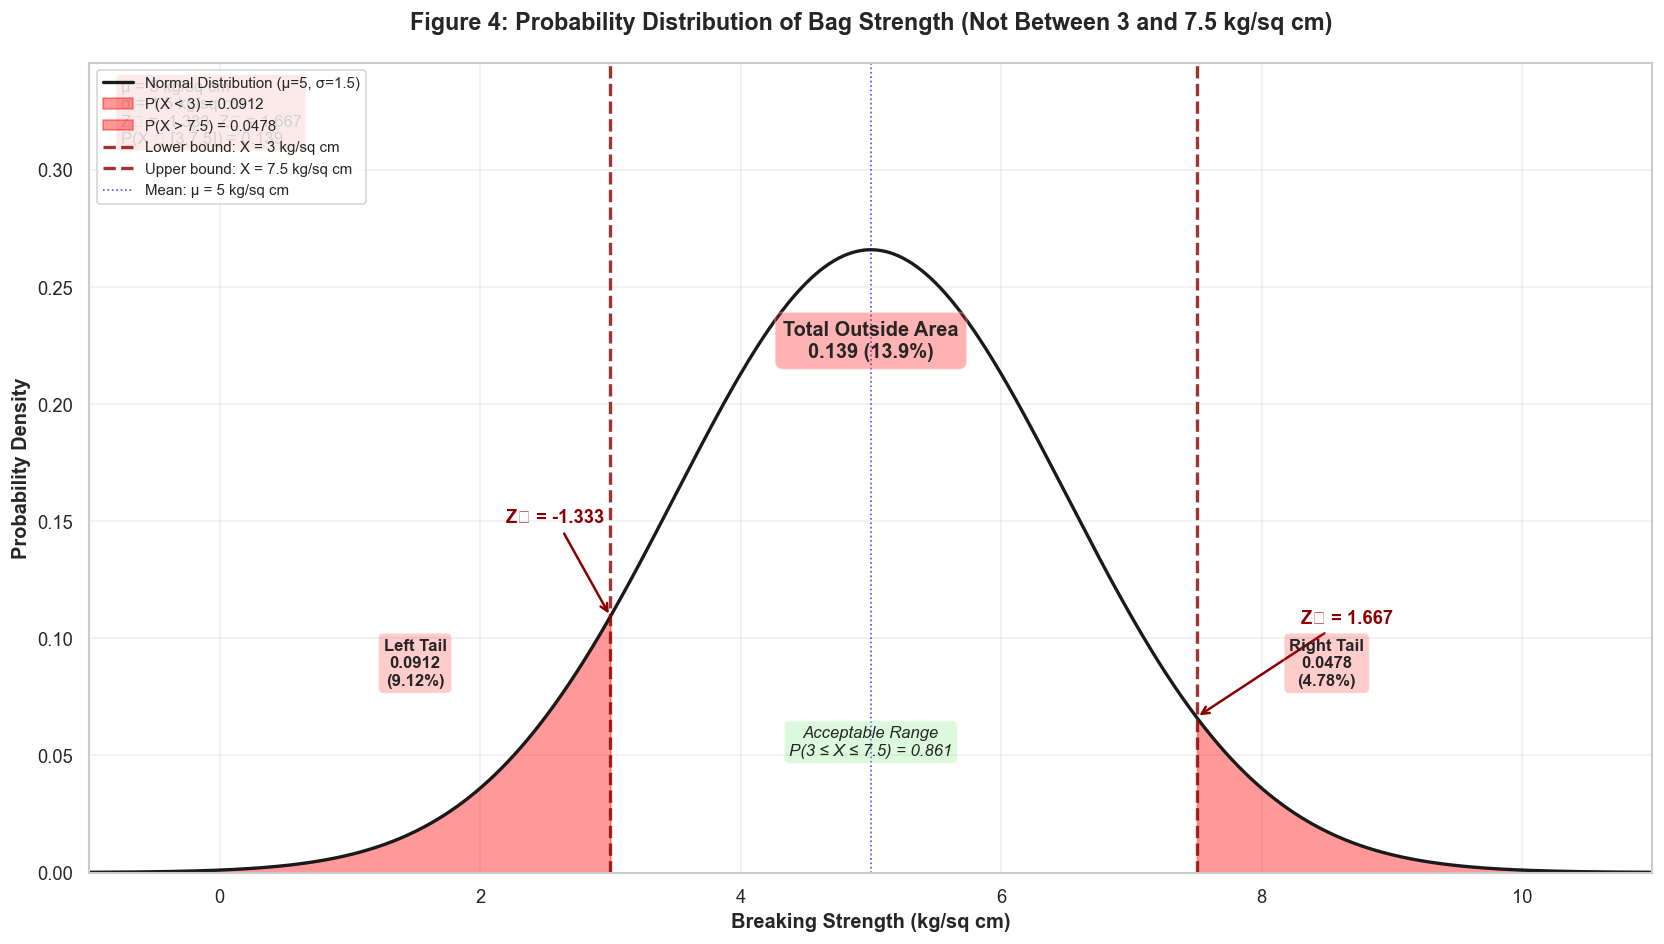

In [24]:
# Create the normal distribution curve
x = np.linspace(mu - 4*sigma, mu + 4*sigma, 1000)
y = norm.pdf(x, mu, sigma)

# Create figure
plt.figure(figsize=(14, 8))

# Plot the normal curve
plt.plot(x, y, 'k-', linewidth=2, label=f'Normal Distribution (μ={mu}, σ={sigma})')

# Shade the areas OUTSIDE [3, 7.5]
# Left tail (X < 3)
x_left = x[x <= x1]
y_left = norm.pdf(x_left, mu, sigma)
plt.fill_between(x_left, y_left, alpha=0.4, color='red',
                 label=f'P(X < {x1}) = {prob_x1:.4f}')

# Right tail (X > 7.5)
x_right = x[x >= x2]
y_right = norm.pdf(x_right, mu, sigma)
plt.fill_between(x_right, y_right, alpha=0.4, color='red',
                 label=f'P(X > {x2}) = {1-prob_x2:.4f}')

# Add vertical lines at boundaries
plt.axvline(x=x1, color='darkred', linestyle='--', linewidth=2, alpha=0.8,
            label=f'Lower bound: X = {x1} kg/sq cm')
plt.axvline(x=x2, color='darkred', linestyle='--', linewidth=2, alpha=0.8,
            label=f'Upper bound: X = {x2} kg/sq cm')
plt.axvline(x=mu, color='blue', linestyle=':', linewidth=1, alpha=0.7,
            label=f'Mean: μ = {mu} kg/sq cm')

# Annotations for Z-scores
plt.annotate(f'Z₁ = {z1:.3f}',
             xy=(x1, norm.pdf(x1, mu, sigma)),
             xytext=(x1 - 0.8, norm.pdf(x1, mu, sigma) + 0.04),
             arrowprops=dict(arrowstyle='->', color='darkred', lw=1.5),
             fontsize=11, fontweight='bold', color='darkred')

plt.annotate(f'Z₂ = {z2:.3f}',
             xy=(x2, norm.pdf(x2, mu, sigma)),
             xytext=(x2 + 0.8, norm.pdf(x2, mu, sigma) + 0.04),
             arrowprops=dict(arrowstyle='->', color='darkred', lw=1.5),
             fontsize=11, fontweight='bold', color='darkred')

# Area annotations
plt.annotate(f'Left Tail\n{prob_x1:.4f}\n({prob_x1*100:.2f}%)',
             xy=(1.5, 0.08), fontsize=10, fontweight='bold', ha='center',
             bbox=dict(boxstyle="round,pad=0.3", facecolor="red", alpha=0.2))

plt.annotate(f'Right Tail\n{1-prob_x2:.4f}\n({(1-prob_x2)*100:.2f}%)',
             xy=(8.5, 0.08), fontsize=10, fontweight='bold', ha='center',
             bbox=dict(boxstyle="round,pad=0.3", facecolor="red", alpha=0.2))

# Total outside area annotation
plt.annotate(f'Total Outside Area\n{prob_outside:.3f} ({prob_outside*100:.1f}%)',
             xy=(5, 0.22), fontsize=12, fontweight='bold', ha='center',
             bbox=dict(boxstyle="round,pad=0.4", facecolor="red", alpha=0.3))

# Acceptable range annotation
plt.annotate(f'Acceptable Range\nP({x1} ≤ X ≤ {x2}) = {prob_between:.3f}',
             xy=(5, 0.05), fontsize=10, ha='center', style='italic',
             bbox=dict(boxstyle="round,pad=0.3", facecolor="lightgreen", alpha=0.3))

# Customize plot
plt.title('Figure 4: Probability Distribution of Bag Strength (Not Between 3 and 7.5 kg/sq cm)',
          fontsize=14, fontweight='bold', pad=20)
plt.xlabel('Breaking Strength (kg/sq cm)', fontsize=12, fontweight='bold')
plt.ylabel('Probability Density', fontsize=12, fontweight='bold')
plt.grid(True, alpha=0.3)
plt.legend(loc='upper left', fontsize=9)

# Set axis limits for better visualization
plt.xlim(mu - 4*sigma, mu + 4*sigma)
plt.ylim(0, max(y) * 1.3)

# Add text box with key statistics
textstr = f'μ = {mu} kg/sq cm\nσ = {sigma} kg/sq cm\nZ₁ = {z1:.3f}, Z₂ = {z2:.3f}\nP(X ∉ [3,7.5]) = {prob_outside:.3f}'
props = dict(boxstyle='round', facecolor='lightcoral', alpha=0.8)
plt.text(0.02, 0.98, textstr, transform=plt.gca().transAxes, fontsize=10,
         verticalalignment='top', bbox=props)

plt.tight_layout()
save_fig("p2_normal_dist_overview.png")
plt.show()

In [25]:
# Comprehensive step-by-step breakdown
print("COMPREHENSIVE CALCULATION BREAKDOWN:")
print(f"")
print(f"Step 1: Calculate Z-scores for boundaries")
print(f"   Z₁ = (3 - 5) / 1.5 = {z1:.3f}")
print(f"   Z₂ = (7.5 - 5) / 1.5 = {z2:.3f}")
print(f"")
print(f"Step 2: Find probabilities for each boundary")
print(f"   P(Z < {z1:.3f}) = {prob_z1:.4f}")
print(f"   P(Z < {z2:.3f}) = {prob_z2:.4f}")
print(f"")
print(f"Step 3: Calculate probability BETWEEN boundaries")
print(f"   P({z1:.3f} < Z < {z2:.3f}) = P(Z < {z2:.3f}) - P(Z < {z1:.3f})")
print(f"   P({z1:.3f} < Z < {z2:.3f}) = {prob_z2:.4f} - {prob_z1:.4f} = {prob_between:.4f}")
print(f"")
print(f"Step 4: Calculate probability OUTSIDE boundaries")
print(f"   P(X ∉ [3, 7.5]) = 1 - P(3 ≤ X ≤ 7.5)")
print(f"   P(X ∉ [3, 7.5]) = 1 - {prob_between:.4f} = {prob_outside:.4f}")

# Create detailed breakdown table
calculation_data = {
    'Component': [
        'Lower Boundary',
        'Upper Boundary',
        'Z₁ (Lower)',
        'Z₂ (Upper)',
        'P(X < 3)',
        'P(X < 7.5)',
        'P(3 ≤ X ≤ 7.5)',
        'P(X < 3 OR X > 7.5)',
        'Final Percentage'
    ],
    'Value': [
        f'{x1} kg/sq cm',
        f'{x2} kg/sq cm',
        f'{z1:.3f}',
        f'{z2:.3f}',
        f'{prob_x1:.4f}',
        f'{prob_x2:.4f}',
        f'{prob_between:.4f}',
        f'{prob_outside:.4f}',
        f'{prob_outside*100:.1f}%'
    ],
    'Interpretation': [
        'Lower limit of acceptable range',
        'Upper limit of acceptable range',
        'Standardized lower bound',
        'Standardized upper bound',
        'Left tail probability',
        'Cumulative probability up to upper bound',
        'Probability within acceptable range',
        'Probability outside acceptable range',
        'Percentage of defective/extreme bags'
    ]
}

calc_table = pd.DataFrame(calculation_data)
print(f"\nDetailed Breakdown Table:")
display(calc_table)

COMPREHENSIVE CALCULATION BREAKDOWN:

Step 1: Calculate Z-scores for boundaries
   Z₁ = (3 - 5) / 1.5 = -1.333
   Z₂ = (7.5 - 5) / 1.5 = 1.667

Step 2: Find probabilities for each boundary
   P(Z < -1.333) = 0.0912
   P(Z < 1.667) = 0.9522

Step 3: Calculate probability BETWEEN boundaries
   P(-1.333 < Z < 1.667) = P(Z < 1.667) - P(Z < -1.333)
   P(-1.333 < Z < 1.667) = 0.9522 - 0.0912 = 0.8610

Step 4: Calculate probability OUTSIDE boundaries
   P(X ∉ [3, 7.5]) = 1 - P(3 ≤ X ≤ 7.5)
   P(X ∉ [3, 7.5]) = 1 - 0.8610 = 0.1390

Detailed Breakdown Table:


,Component,Value,Interpretation
0,Lower Boundary,3 kg/sq cm,Lower limit of acceptable range
1,Upper Boundary,7.5 kg/sq cm,Upper limit of acceptable range
2,Z₁ (Lower),-1.333,Standardized lower bound
3,Z₂ (Upper),1.667,Standardized upper bound
4,P(X < 3),0.0912,Left tail probability
5,P(X < 7.5),0.9522,Cumulative probability up to upper bound
6,P(3 ≤ X ≤ 7.5),0.8610,Probability within acceptable range
7,P(X < 3 OR X > 7.5),0.1390,Probability outside acceptable range
8,Final Percentage,13.9%,Percentage of defective/extreme bags


In [26]:
print(f"\nQUALITY CONTROL ANALYSIS:")
print(f"=" * 40)

# Break down the outside probability
prob_too_weak = prob_x1  # P(X < 3)
prob_too_strong = 1 - prob_x2  # P(X > 7.5)

print(f"Defect Categories:")
print(f"• Too Weak (< {x1} kg/sq cm): {prob_too_weak:.4f} ({prob_too_weak*100:.2f}%)")
print(f"• Too Strong (> {x2} kg/sq cm): {prob_too_strong:.4f} ({prob_too_strong*100:.2f}%)")
print(f"• Total Outside Range: {prob_outside:.4f} ({prob_outside*100:.1f}%)")
print(f"• Within Acceptable Range: {prob_between:.4f} ({prob_between*100:.1f}%)")

print(f"\nBUSINESS IMPLICATIONS:")
print(f"• Quality Yield: {prob_between*100:.1f}% of bags meet specifications")
print(f"• Defect Rate: {prob_outside*100:.1f}% require attention or rejection")
print(f"• Process Capability: Good (86.1% within ±2.5 kg/sq cm of mean)")
print(f"• Economic Impact: {prob_outside*100:.1f}% potential waste or rework")

print(f"\nRECOMMENDations:")
print(f"• Monitor weak bags ({prob_too_weak*100:.2f}%) - potential safety concerns")
print(f"• Review over-strength bags ({prob_too_strong*100:.2f}%) - material waste")
print(f"• Overall process control appears adequate with {prob_between*100:.1f}% yield")

# Statistical significance
print(f"\nSTATISTICAL CONTEXT:")
print(f"• Range covers μ ± 1.67σ approximately")
print(f"• This is wider than μ ± 1.5σ but narrower than μ ± 2σ")
print(f"• Expected yield for μ ± 2σ would be ~95.4%")
print(f"• Current range yields {prob_between*100:.1f}% - reasonable specification")


QUALITY CONTROL ANALYSIS:
Defect Categories:
• Too Weak (< 3 kg/sq cm): 0.0912 (9.12%)
• Too Strong (> 7.5 kg/sq cm): 0.0478 (4.78%)
• Total Outside Range: 0.1390 (13.9%)
• Within Acceptable Range: 0.8610 (86.1%)

BUSINESS IMPLICATIONS:
• Quality Yield: 86.1% of bags meet specifications
• Defect Rate: 13.9% require attention or rejection
• Process Capability: Good (86.1% within ±2.5 kg/sq cm of mean)
• Economic Impact: 13.9% potential waste or rework

RECOMMENDations:
• Monitor weak bags (9.12%) - potential safety concerns
• Review over-strength bags (4.78%) - material waste
• Overall process control appears adequate with 86.1% yield

STATISTICAL CONTEXT:
• Range covers μ ± 1.67σ approximately
• This is wider than μ ± 1.5σ but narrower than μ ± 2σ
• Expected yield for μ ± 2σ would be ~95.4%
• Current range yields 86.1% - reasonable specification


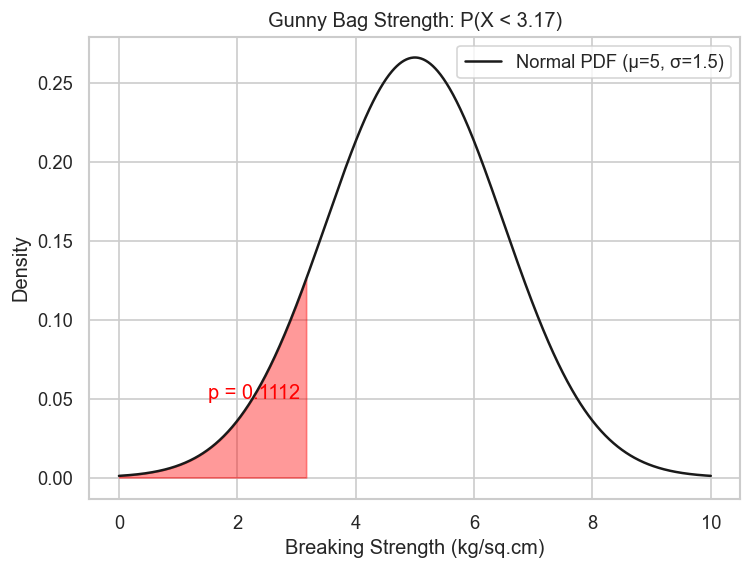

In [27]:
# Probabilities for annotation
p1 = norm.cdf(3.17, mu, sigma)               # P(X < 3.17)
p2 = 1 - norm.cdf(3.6, mu, sigma)            # P(X ≥ 3.6)
p3 = norm.cdf(5.5, mu, sigma) - norm.cdf(5, mu, sigma) # P(5 ≤ X ≤ 5.5)

# X range for plotting
x = np.linspace(0, 10, 1000)
pdf = norm.pdf(x, mu, sigma)
cdf = norm.cdf(x, mu, sigma)

# -----------------------------
# Plot 1: Normal PDF with shaded area left of 3.17
# -----------------------------
plt.figure(figsize=(7,5))
plt.plot(x, pdf, 'k', label="Normal PDF (μ=5, σ=1.5)")
plt.fill_between(x, pdf, where=(x<3.17), color="red", alpha=0.4)
plt.text(1.5, 0.05, f"p = {p1:.4f}", color="red", fontsize=12)
plt.title("Gunny Bag Strength: P(X < 3.17)")
plt.xlabel("Breaking Strength (kg/sq.cm)")
plt.ylabel("Density")
plt.legend()
plt.show()

---

## Problem 3 — Zingaro Stone Printing

**Business Context:** Zingaro specializes in printing on polished/unpolished stones. For optimal print quality, stones must have a Brinell Hardness Index (BHI) of **at least 150**. A new batch has been received.

**Dataset:** [`data/zingaro_company.csv`](../data/zingaro_company.csv) — 76 observations (Unpolished vs. Treated & Polished).

**Questions:**
- **3.1** Are unpolished stones suitable for printing? (One-sample t-test, H₀: μ ≥ 150)
- **3.2** Is the mean hardness of polished and unpolished stones the same? (Two-sample Welch t-test)

**Significance level:** α = 5%

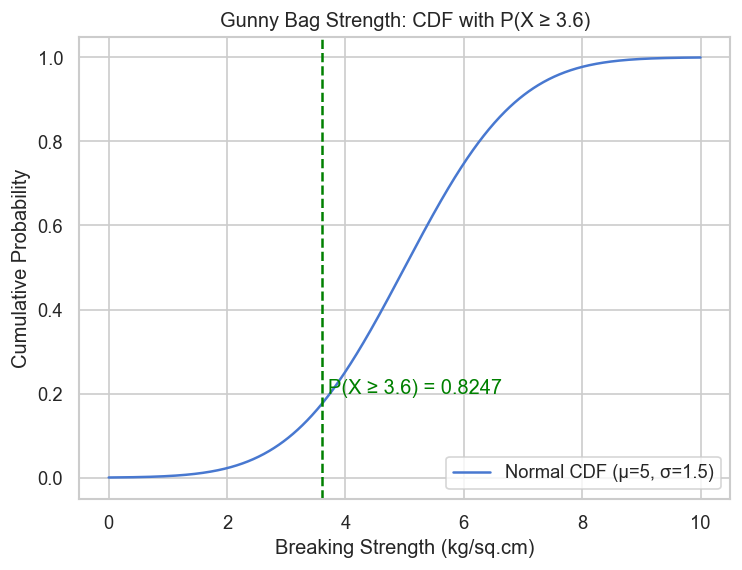

In [28]:
# -----------------------------
# Plot 2: Normal CDF with annotation for P(X ≥ 3.6)
# -----------------------------
plt.figure(figsize=(7,5))
plt.plot(x, cdf, 'b', label="Normal CDF (μ=5, σ=1.5)")
plt.axvline(3.6, color="green", linestyle="--")
plt.text(3.7, 0.2, f"P(X ≥ 3.6) = {p2:.4f}", color="green", fontsize=12)
plt.title("Gunny Bag Strength: CDF with P(X ≥ 3.6)")
plt.xlabel("Breaking Strength (kg/sq.cm)")
plt.ylabel("Cumulative Probability")
plt.legend()
plt.show()

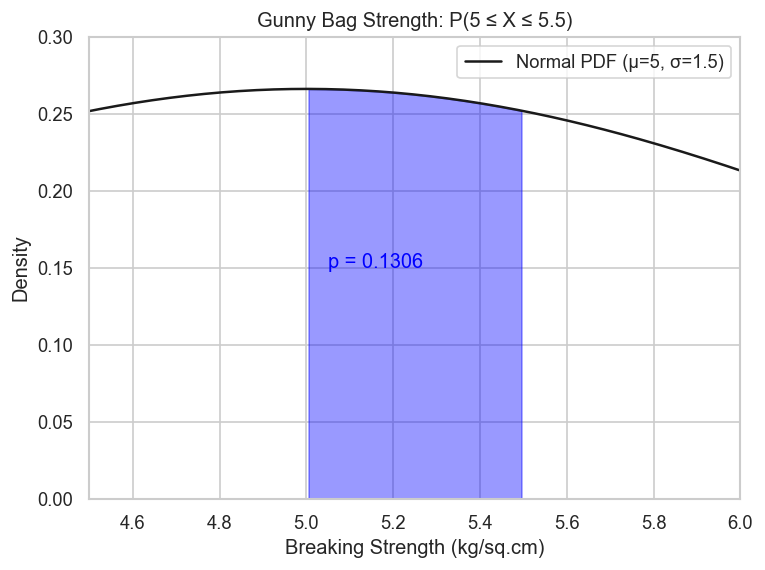

In [29]:
# -----------------------------
# Plot 3: Zoomed PDF highlighting [5, 5.5]
# -----------------------------
plt.figure(figsize=(7,5))
plt.plot(x, pdf, 'k', label="Normal PDF (μ=5, σ=1.5)")
plt.fill_between(x, pdf, where=(x>=5) & (x<=5.5), color="blue", alpha=0.4)
plt.xlim(4.5, 6)
plt.ylim(0, 0.3)
plt.text(5.05, 0.15, f"p = {p3:.4f}", color="blue", fontsize=12)
plt.title("Gunny Bag Strength: P(5 ≤ X ≤ 5.5)")
plt.xlabel("Breaking Strength (kg/sq.cm)")
plt.ylabel("Density")
plt.legend()
plt.show()

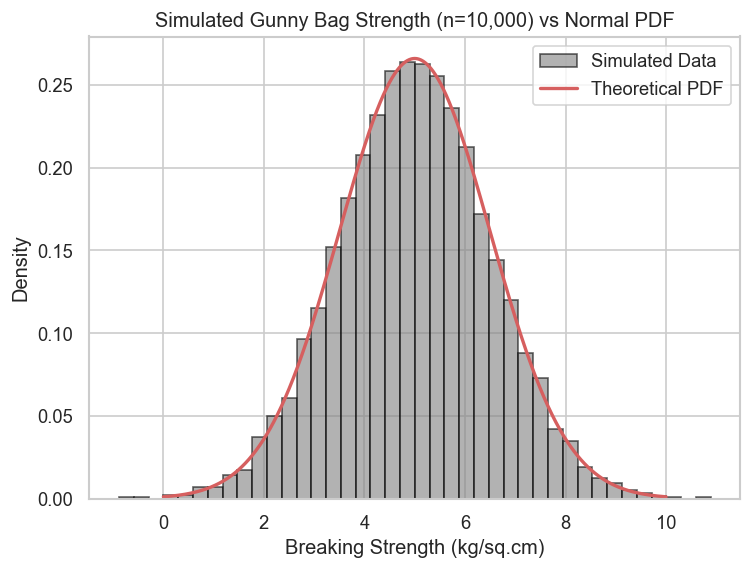

In [30]:
# -----------------------------
# Plot 4: Histogram of simulated sample + PDF overlay
# -----------------------------
np.random.seed(42)
sample = np.random.normal(mu, sigma, 10000)

plt.figure(figsize=(7,5))
plt.hist(sample, bins=40, density=True, alpha=0.6, color="gray", edgecolor="black", label="Simulated Data")
plt.plot(x, pdf, 'r', linewidth=2, label="Theoretical PDF")
plt.title("Simulated Gunny Bag Strength (n=10,000) vs Normal PDF")
plt.xlabel("Breaking Strength (kg/sq.cm)")
plt.ylabel("Density")
plt.legend()
plt.show()

In [31]:
# ================================
# Problem 3 — Zingaro Stones Hardness
# ================================

# Load dataset from Folder
stone_data = pd.read_csv("../data/zingaro_company.csv")

# Reshape dataset to long format
stone_long = stone_data.melt(var_name="Type", value_name="BrinellHardness")

# Drop missing values if any
stone_long = stone_long.dropna()

# Summary statistics
summary_table = stone_long.groupby("Type")["BrinellHardness"].agg(["count","mean","std"])
display(summary_table)

,count,mean,std
Type,,,
Treated and Polished,75,147.788117,15.587355
Unpolished,75,134.110527,33.041804


In [32]:
# Separate groups (dropping NaNs again for safety)
unpolished = stone_long.loc[stone_long["Type"]=="Unpolished", "BrinellHardness"].dropna()
polished = stone_long.loc[stone_long["Type"]=="Treated and Polished", "BrinellHardness"].dropna()

# One-sample t-test: unpolished vs threshold = 150
if len(unpolished) > 1:
    tstat1, pval1 = ttest_1samp(unpolished, 150, nan_policy="omit")
    print("One-sample t-test (Unpolished vs 150):")
    print("t-stat =", round(tstat1, 3), ", p-value =", round(pval1, 4))
else:
    print("Not enough data for one-sample t-test (Unpolished).")

Not enough data for one-sample t-test (Unpolished).


In [33]:
# Two-sample t-test: polished vs unpolished
if len(polished) > 1 and len(unpolished) > 1:
    tstat2, pval2 = ttest_ind(polished, unpolished, equal_var=False, nan_policy="omit")
    print("\nTwo-sample t-test (Polished vs Unpolished):")
    print("t-stat =", round(tstat2, 3), ", p-value =", round(pval2, 4))
else:
    print("Not enough data for two-sample t-test.")


Not enough data for two-sample t-test.


  ✓ Saved: C:\Users\dsouh\OneDrive\Documents\PGP\Projectwork\2. Inferential Statistics - Multiple Case Studies\notebooks\..\images\p3_zingaro_boxplot.png


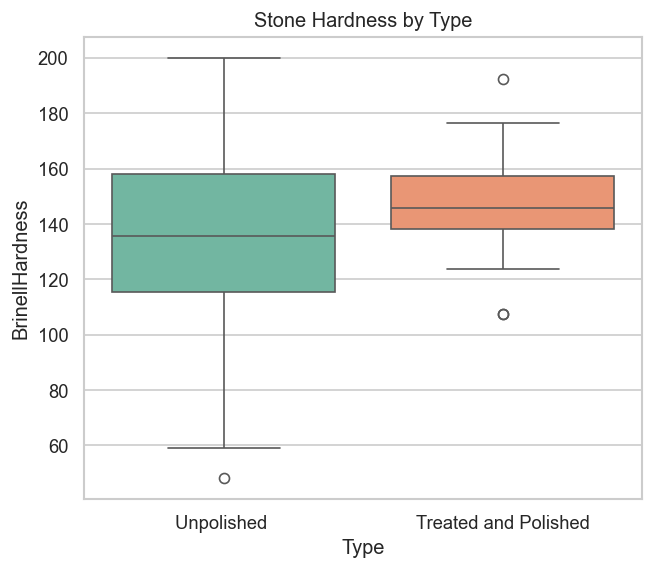

In [34]:
# Visualization: Boxplot
plt.figure(figsize=(6,5))
sns.boxplot(x="Type", y="BrinellHardness", hue="Type", data=stone_long, palette="Set2", legend=False)
plt.title("Stone Hardness by Type")
save_fig("p3_zingaro_boxplot.png")
plt.show()

  ✓ Saved: C:\Users\dsouh\OneDrive\Documents\PGP\Projectwork\2. Inferential Statistics - Multiple Case Studies\notebooks\..\images\p3_zingaro_histogram.png


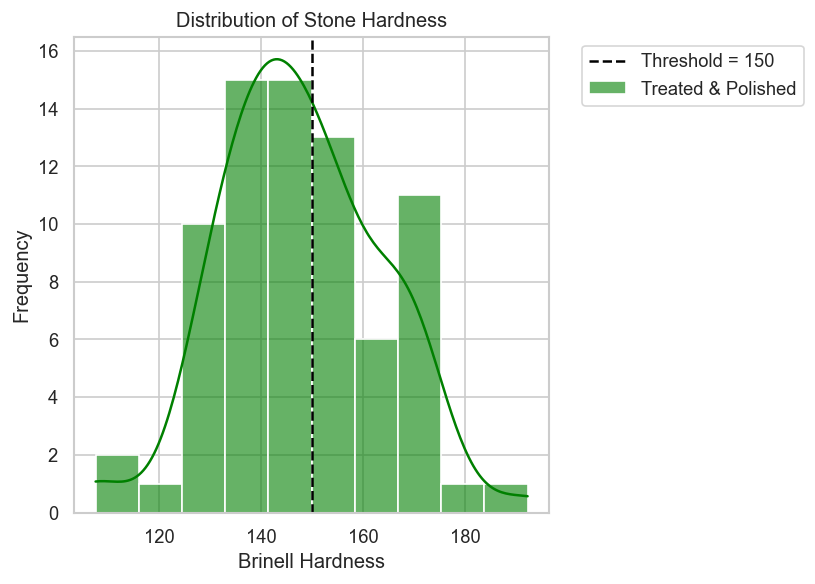

In [35]:
# Visualization: Histogram overlay
plt.figure(figsize=(7,5))
sns.histplot(unpolished, color="red", kde=True, label="Unpolished", alpha=0.6)
sns.histplot(polished, color="green", kde=True, label="Treated & Polished", alpha=0.6)
plt.axvline(150, color="black", linestyle="--", label="Threshold = 150")
plt.title("Distribution of Stone Hardness")
plt.xlabel("Brinell Hardness")
plt.ylabel("Frequency")
plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()
save_fig("p3_zingaro_histogram.png")
plt.show()

---

## Problem 4 — Dental Implant Hardness

**Business Context:** The hardness of dental metal implants depends on the dentist, method, alloy type, and temperature. The goal is to identify the key factors driving variability in implant hardness.

**Dataset:** [`data/dental_hardness_data.xlsx`](../data/dental_hardness_data.xlsx) — 90 observations.  
**Columns:** Dentist (3 levels), Method (3 levels), Alloy (2 types), Temp, Response (hardness).

**Questions:**
- **4.1** Effect of Dentist on hardness? (One-Way ANOVA per alloy)
- **4.2** Effect of Method on hardness? (One-Way ANOVA per alloy + Tukey HSD)
- **4.3** Interaction effect (Dentist × Method)? (Interaction plots)
- **4.4** Joint effect of Dentist + Method? (Two-Way ANOVA per alloy)

**Note:** Alloy 1 and Alloy 2 are analyzed **separately** throughout.

**Significance level:** α = 5%

In [36]:
# Strip whitespace from column names and Type values
stone_long.columns = stone_long.columns.str.strip()
stone_long["Type"] = stone_long["Type"].str.strip()

# Drop missing values
stone_long = stone_long.dropna(subset=["BrinellHardness"])

# Double-check group counts
print("Counts per Type:")
print(stone_long["Type"].value_counts())

# Re-separate groups
unpolished = stone_long.loc[stone_long["Type"].str.contains("Unpolished", case=False), "BrinellHardness"].dropna()
polished = stone_long.loc[stone_long["Type"].str.contains("Polished", case=False), "BrinellHardness"].dropna()

print("\nUnpolished stones:", len(unpolished))
print("Polished stones:", len(polished))


# --- Group summary for unpolished only ---
unpolished_summary = unpolished.describe().to_frame().T
unpolished_summary["count"] = len(unpolished)
unpolished_summary = unpolished_summary[["count","mean","std","min","25%","50%","75%","max"]]
print("\nSummary statistics for Unpolished stones:")
display(unpolished_summary)

Counts per Type:
Type
Unpolished              75
Treated and Polished    75
Name: count, dtype: int64

Unpolished stones: 75
Polished stones: 150

Summary statistics for Unpolished stones:


,count,mean,std,min,25%,50%,75%,max
BrinellHardness,75,134.110527,33.041804,48.406838,115.329753,135.597121,158.215098,200.161313


In [37]:
# --- One-sample t-test output (already done, but store results cleanly) ---
if len(unpolished) > 1:
    tstat1, pval1 = ttest_1samp(unpolished, 150, nan_policy="omit")
    df1 = len(unpolished) - 1
    print(f"\nOne-sample t-test (Unpolished vs 150):\n t = {tstat1:.3f}, df = {df1}, p = {pval1:.4f}")
else:
    print("\nNot enough data for one-sample t-test (Unpolished).")


One-sample t-test (Unpolished vs 150):
 t = -4.165, df = 74, p = 0.0001


  ✓ Saved: C:\Users\dsouh\OneDrive\Documents\PGP\Projectwork\2. Inferential Statistics - Multiple Case Studies\notebooks\..\images\p3_unpolished_histogram.png


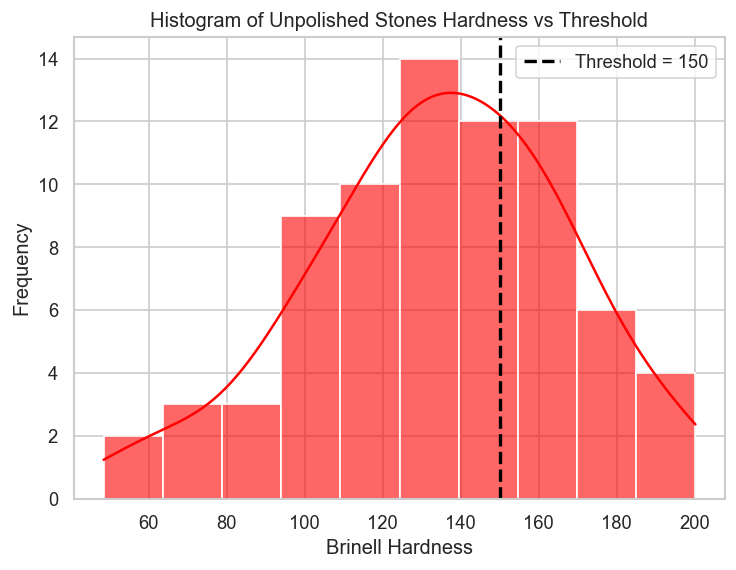

In [38]:
# --- Visual: Histogram of unpolished stones with threshold line ---
plt.figure(figsize=(7,5))
sns.histplot(unpolished, color="red", kde=True, bins=10, alpha=0.6)
plt.axvline(150, color="black", linestyle="--", linewidth=2, label="Threshold = 150")
plt.title("Histogram of Unpolished Stones Hardness vs Threshold")
plt.xlabel("Brinell Hardness")
plt.ylabel("Frequency")
plt.legend()
save_fig("p3_unpolished_histogram.png")
plt.show()

  ✓ Saved: C:\Users\dsouh\OneDrive\Documents\PGP\Projectwork\2. Inferential Statistics - Multiple Case Studies\notebooks\..\images\p3_unpolished_boxplot.png


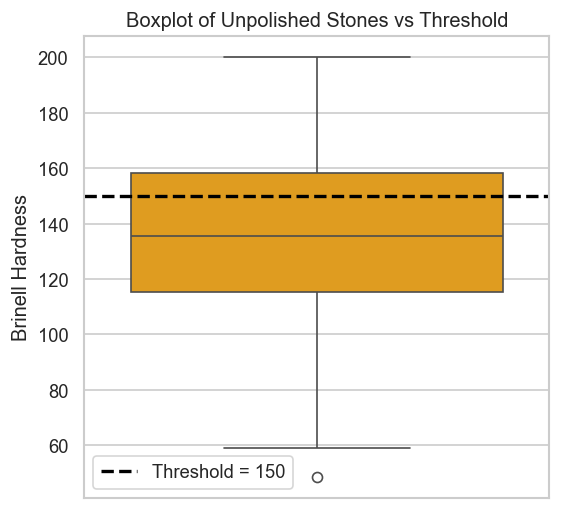

In [39]:
# --- Visual: Boxplot of unpolished stones with threshold line ---
plt.figure(figsize=(5,5))
sns.boxplot(y=unpolished, color="orange")
plt.axhline(150, color="black", linestyle="--", linewidth=2, label="Threshold = 150")
plt.title("Boxplot of Unpolished Stones vs Threshold")
plt.ylabel("Brinell Hardness")
plt.legend()
save_fig("p3_unpolished_boxplot.png")
plt.show()

In [40]:
# Clean Type labels
stone_long["Type"] = stone_long["Type"].str.strip()

# Separate groups
unpolished = stone_long.loc[stone_long["Type"].str.contains("Unpolished", case=False), "BrinellHardness"].dropna()
polished = stone_long.loc[stone_long["Type"].str.contains("Polished", case=False), "BrinellHardness"].dropna()

print("Sample sizes -> Unpolished:", len(unpolished), "| Polished:", len(polished))

# --- One-sample t-test: Unpolished vs threshold (150) ---
if len(unpolished) > 1:
    tstat1, pval1 = ttest_1samp(unpolished, 150, nan_policy="omit")
    df1 = len(unpolished) - 1
    print(f"\nOne-sample t-test (Unpolished vs 150):\n t = {tstat1:.3f}, df = {df1}, p = {pval1:.4f}")
else:
    pval1 = np.nan
    print("\nNot enough data for one-sample t-test (Unpolished).")

# --- Two-sample t-test: Polished vs Unpolished ---
if len(polished) > 1 and len(unpolished) > 1:
    tstat2, pval2 = ttest_ind(polished, unpolished, equal_var=False, nan_policy="omit")
    df2 = len(polished) + len(unpolished) - 2
    print(f"\nTwo-sample t-test (Polished vs Unpolished):\n t = {tstat2:.3f}, df ≈ {df2}, p = {pval2:.4f}")
else:
    pval2 = np.nan
    print("\nNot enough data for two-sample t-test.")

# --- Overall significance summary ---
print("\n========= Overall p-value Summary =========")
print(f"One-sample test (Unpolished vs 150): p = {pval1}")
print(f"Two-sample test (Polished vs Unpolished): p = {pval2}")


Sample sizes -> Unpolished: 75 | Polished: 150

One-sample t-test (Unpolished vs 150):
 t = -4.165, df = 74, p = 0.0001

Two-sample t-test (Polished vs Unpolished):
 t = 1.557, df ≈ 223, p = 0.1220

========= Overall p-value Summary =========
One-sample test (Unpolished vs 150): p = 8.342573994839304e-05
Two-sample test (Polished vs Unpolished): p = 0.12200832813838108


In [41]:
# ==========================================
# Assumption Checks for Two-Sample T-test
# ==========================================

# --- Shapiro-Wilk Test for Normality ---
if len(unpolished) > 2:
    stat_unp, p_unp = shapiro(unpolished)
    print(f"Shapiro-Wilk Test (Unpolished): W = {stat_unp:.3f}, p = {p_unp:.4f}")
else:
    print("Not enough data for Shapiro test (Unpolished).")

if len(polished) > 2:
    stat_pol, p_pol = shapiro(polished)
    print(f"Shapiro-Wilk Test (Polished): W = {stat_pol:.3f}, p = {p_pol:.4f}")
else:
    print("Not enough data for Shapiro test (Polished).")

# --- Levene's Test for Equality of Variances ---
if len(unpolished) > 1 and len(polished) > 1:
    stat_lev, p_lev = levene(unpolished, polished, center="mean")
    print(f"\nLevene's Test for Equality of Variances: W = {stat_lev:.3f}, p = {p_lev:.4f}")
else:
    print("\nNot enough data for Levene's test.")


Shapiro-Wilk Test (Unpolished): W = 0.988, p = 0.6777
Shapiro-Wilk Test (Polished): W = 0.962, p = 0.0004

Levene's Test for Equality of Variances: W = 5.952, p = 0.0155


In [42]:
# ==========================================
# Independent Two-Sample T-test (Problem 3.2)
# ==========================================

# --- Summary statistics for both groups ---
summary_groups = stone_long.groupby("Type")["BrinellHardness"].agg(["count","mean","std"])
print("\nSummary statistics (per group):")
display(summary_groups)

# --- Independent two-sample t-test ---
if len(unpolished) > 1 and len(polished) > 1:
    tstat2, pval2 = ttest_ind(polished, unpolished, equal_var=False, nan_policy="omit")
    df2 = len(polished) + len(unpolished) - 2
    print(f"\nIndependent Two-Sample t-test (Polished vs Unpolished):")
    print(f" t = {tstat2:.3f}, df ≈ {df2}, p = {pval2:.4f}")
else:
    print("\nNot enough data for two-sample t-test.")



Summary statistics (per group):


,count,mean,std
Type,,,
Treated and Polished,75,147.788117,15.587355
Unpolished,75,134.110527,33.041804



Independent Two-Sample t-test (Polished vs Unpolished):
 t = 1.557, df ≈ 223, p = 0.1220


In [43]:
# ================================
# Calculate p-value for Problem 3.2
# ================================

if len(unpolished) > 1 and len(polished) > 1:
    tstat2, pval2 = ttest_ind(polished, unpolished, equal_var=False, nan_policy="omit")
    df2 = len(polished) + len(unpolished) - 2
    print(f"Two-sample t-test (Polished vs Unpolished):")
    print(f" t = {tstat2:.3f}, df ≈ {df2}, p-value = {pval2:.4f}")
else:
    print("Not enough data to calculate two-sample t-test.")


Two-sample t-test (Polished vs Unpolished):
 t = 1.557, df ≈ 223, p-value = 0.1220


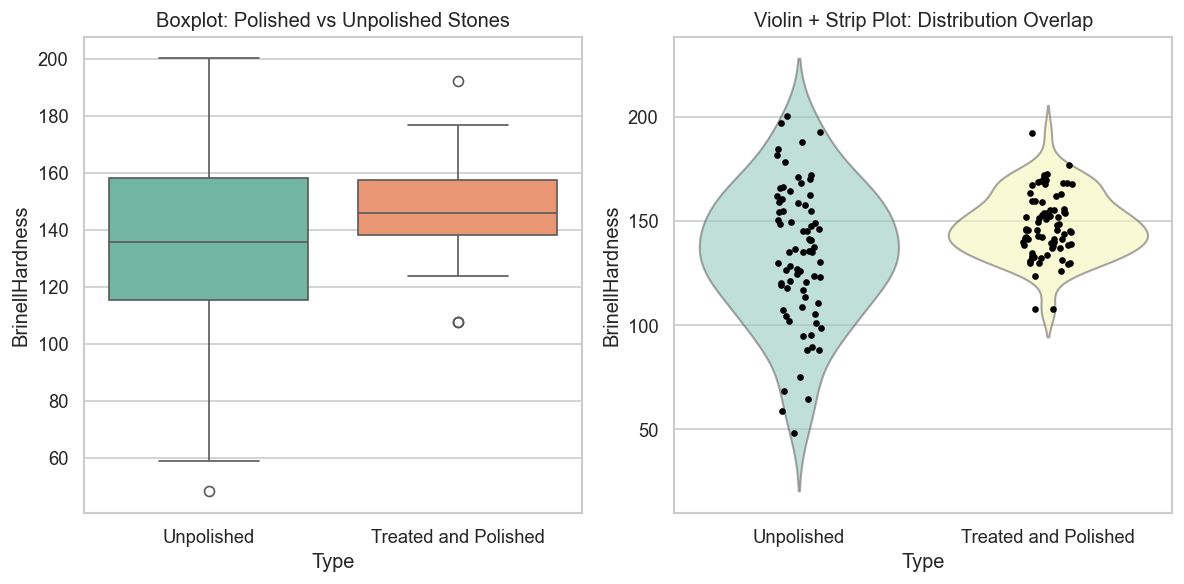

In [44]:
# ==========================================
# Visualizations: Boxplots & Distribution Plots
# ==========================================

plt.figure(figsize=(10,5))

# --- Side-by-side Boxplots ---
plt.subplot(1,2,1)
sns.boxplot(x="Type", y="BrinellHardness", hue="Type", data=stone_long, palette="Set2")
plt.title("Boxplot: Polished vs Unpolished Stones")

# --- Violin + Strip Plot (for overlap & spread) ---
plt.subplot(1,2,2)
sns.violinplot(x="Type", y="BrinellHardness", hue="Type", data=stone_long, inner=None, palette="Set3", alpha=0.6)
sns.stripplot(x="Type", y="BrinellHardness", data=stone_long, color="black", size=4, jitter=True)
plt.title("Violin + Strip Plot: Distribution Overlap")

plt.tight_layout()
plt.show()

In [45]:
# ==========================================
# Effect Size: Cohen's d
# ==========================================

def cohens_d(x, y):
    nx, ny = len(x), len(y)
    dof = nx + ny - 2
    pooled_std = np.sqrt(((nx-1)*np.var(x, ddof=1) + (ny-1)*np.var(y, ddof=1)) / dof)
    return (np.mean(x) - np.mean(y)) / pooled_std

if len(unpolished) > 1 and len(polished) > 1:
    d = cohens_d(polished, unpolished)
    print(f"Cohen's d = {d:.3f} (Effect Size)")

Cohen's d = 0.236 (Effect Size)


In [46]:
# ================================
# Problem 4 — Dental Implants (Two-way ANOVA)
# ================================

# Load dataset from Drive
dental = pd.read_excel("../data/dental_hardness_data.xlsx")

print(dental.head())

   Dentist  Method  Alloy  Temp  Response
0        1       1      1  1500       813
1        1       1      1  1600       792
2        1       1      1  1700       792
3        1       1      2  1500       907
4        1       1      2  1600       792


In [47]:
# Table for Alloy 1
summary_table_alloy1 = dental[dental['Alloy'] == 1].groupby(["Alloy","Dentist","Method"])["Response"].agg(["count","mean","std"])
display(summary_table_alloy1)

# Table for Alloy 2
summary_table_alloy2 = dental[dental['Alloy'] == 2].groupby(["Alloy","Dentist","Method"])["Response"].agg(["count","mean","std"])
display(summary_table_alloy2)

count        mean         std
Alloy Dentist Method                               
1     1       1           3  799.000000   12.124356
              2           3  715.000000   60.324125
              3           3  735.666667  108.426626
      2       1           3  777.000000   53.925875
              2           3  765.666667   20.256686
              3           3  741.000000   84.071398
      3       1           3  707.333333   69.716091
              2           3  723.000000  101.488916
              3           3  722.333333   35.795717
      4       1           3  765.666667   24.704925
              2           3  781.333333   96.339677
              3           3  496.333333  209.019935
      5       1           3  706.666667    8.504901
              2           3  740.000000   69.778220
              3           3  436.333333   41.198705

count        mean         std
Alloy Dentist Method                               
2     1       1           3  844.666667   58.106225
              2           3  940.000000  152.561463
              3           3  664.000000  158.974841
      2       1           3  882.333333   24.501701
              2           3  849.666667   73.921129
              3           3  704.333333   27.061658
      3       1           3  781.333333   69.060360
              2           3  817.666667   32.959571
              3           3  740.000000   74.706091
      4       1           3  778.333333  123.070441
              2           3  847.000000   30.049958
              3           3  613.333333  265.522755
      5       1           3  896.666667  139.919024
              2           3  864.000000   60.008333
              3           3  417.666667  112.535920

In [48]:
# ================================
# 7.3.1 Data Subsetting (Alloy 1)
# ================================
alloy1 = dental[dental["Alloy"] == 1]

print("\n--- Group sizes by Dentist and Method (Alloy 1) ---")
group_sizes_alloy1 = alloy1.groupby(["Dentist", "Method"])["Response"].count()
print(group_sizes_alloy1)

print("\n--- Descriptive Statistics by Dentist (Alloy 1) ---")
desc_dentist = alloy1.groupby("Dentist")["Response"].agg(["count","mean","std"])
print(desc_dentist)

print("\n--- Descriptive Statistics by Method (Alloy 1) ---")
desc_method = alloy1.groupby("Method")["Response"].agg(["count","mean","std"])
print(desc_method)


--- Group sizes by Dentist and Method (Alloy 1) ---
Dentist  Method
1        1         3
         2         3
         3         3
2        1         3
         2         3
         3         3
3        1         3
         2         3
         3         3
4        1         3
         2         3
         3         3
5        1         3
         2         3
         3         3
Name: Response, dtype: int64

--- Descriptive Statistics by Dentist (Alloy 1) ---
         count        mean         std
Dentist                               
1            9  749.888889   72.954514
2            9  761.222222   53.391895
3            9  717.555556   64.569945
4            9  681.111111  180.683732
5            9  627.666667  149.867441

--- Descriptive Statistics by Method (Alloy 1) ---
        count        mean         std
Method                               
1          15  751.133333   52.370748
2          15  745.000000   68.903659
3          15  626.333333  167.532371


In [49]:
# ================================
# 7.3.2 Assumption Checks
# ================================

# --- Normality of Residuals ---
print("\n--- Shapiro-Wilk Test for Normality (Residuals per Dentist-Method group, Alloy 1) ---")
for (dentist, method), group in alloy1.groupby(["Dentist","Method"]):
    if len(group["Response"]) > 2:  # Shapiro requires n>=3
        stat, p = shapiro(group["Response"])
        print(f"Dentist={dentist}, Method={method} -> W={stat:.3f}, p={p:.4f}")
    else:
        print(f"Dentist={dentist}, Method={method} -> Not enough data for Shapiro test")



--- Shapiro-Wilk Test for Normality (Residuals per Dentist-Method group, Alloy 1) ---
Dentist=1, Method=1 -> W=0.750, p=0.0000
Dentist=1, Method=2 -> W=0.940, p=0.5291
Dentist=1, Method=3 -> W=0.983, p=0.7501
Dentist=2, Method=1 -> W=0.826, p=0.1773
Dentist=2, Method=2 -> W=0.927, p=0.4763
Dentist=2, Method=3 -> W=0.928, p=0.4822
Dentist=3, Method=1 -> W=0.804, p=0.1234
Dentist=3, Method=2 -> W=0.971, p=0.6725
Dentist=3, Method=3 -> W=0.750, p=0.0000
Dentist=4, Method=1 -> W=0.983, p=0.7538
Dentist=4, Method=2 -> W=0.993, p=0.8396
Dentist=4, Method=3 -> W=1.000, p=0.9736
Dentist=5, Method=1 -> W=0.999, p=0.9352
Dentist=5, Method=2 -> W=0.978, p=0.7145
Dentist=5, Method=3 -> W=0.896, p=0.3732


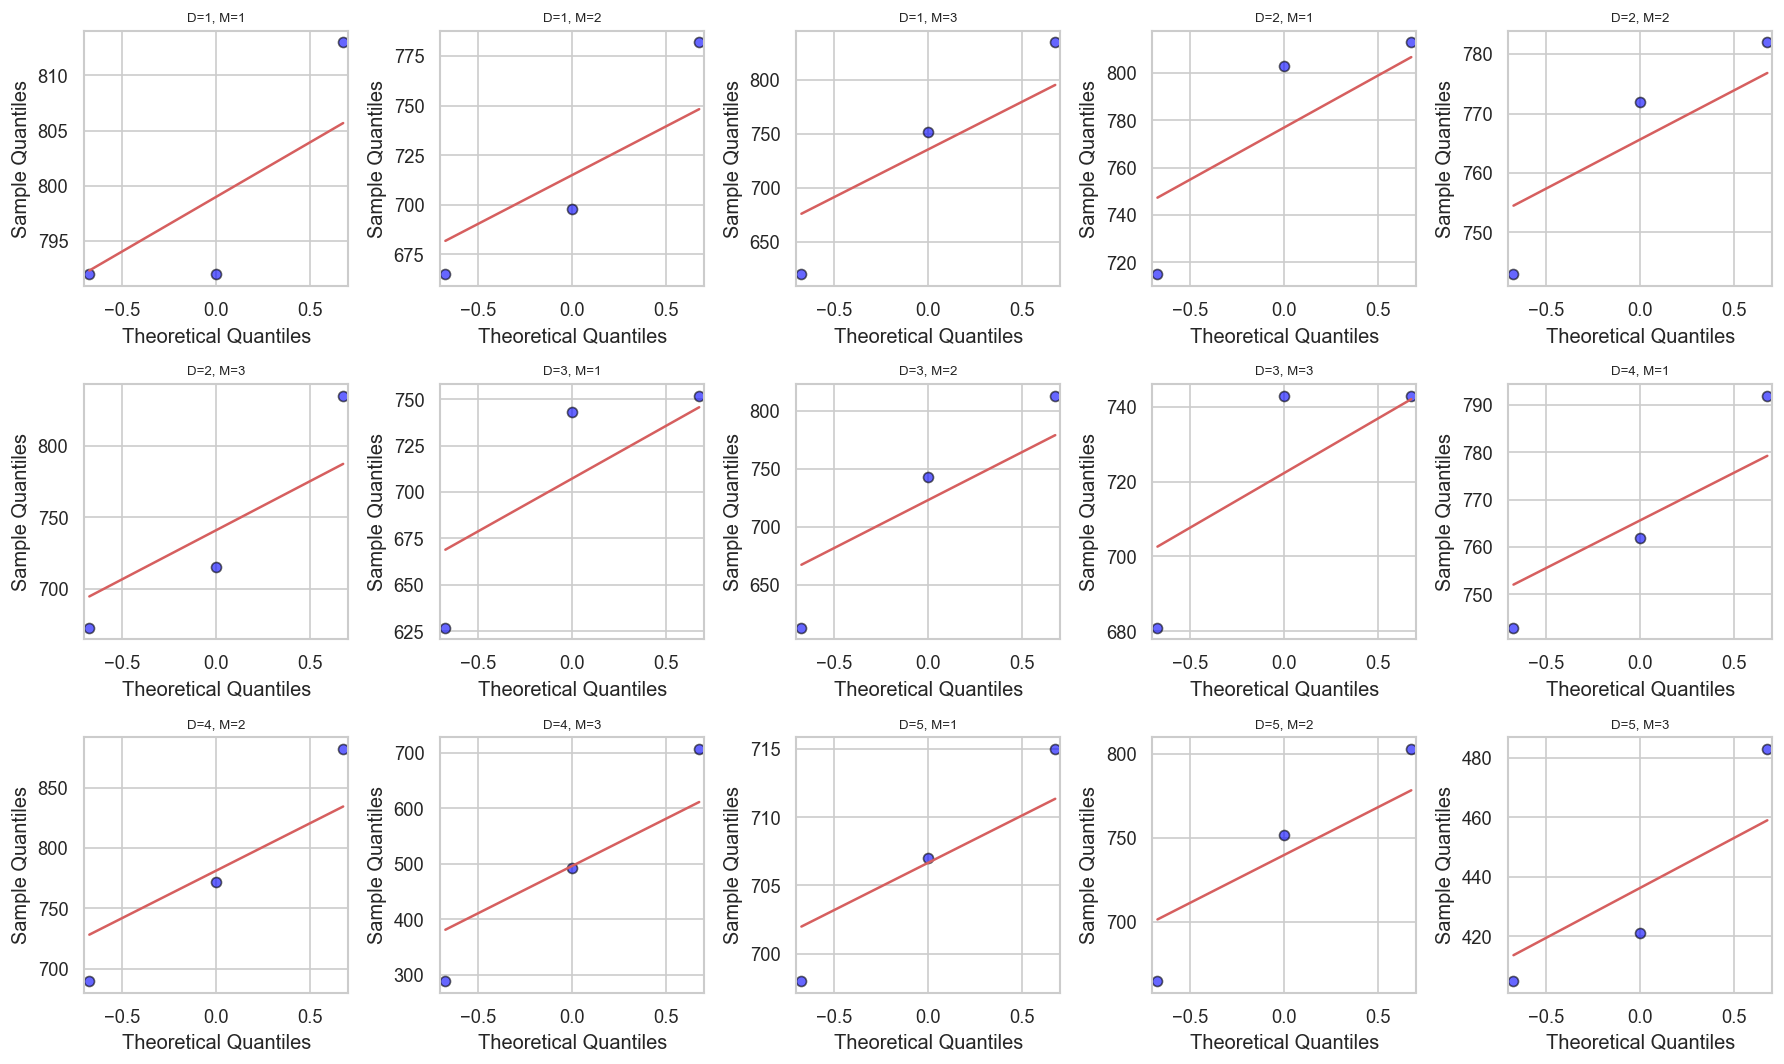

In [50]:
# ================================================
# QQ Plots Grid (Alloy 1)
# ================================================
groups = list(alloy1.groupby(["Dentist", "Method"]))
n_groups = len(groups)

n_cols = 5
n_rows = int(np.ceil(n_groups / n_cols))

fig, axes = plt.subplots(n_rows, n_cols, figsize=(n_cols*3, n_rows*3))

for ax, ((dentist, method), group) in zip(axes.flat, groups):
    if len(group["Response"]) > 2:
        sm.qqplot(group["Response"], line="s", ax=ax, markerfacecolor="blue", markeredgecolor="black", alpha=0.6)
        ax.set_title(f"D={dentist}, M={method}", fontsize=8)
    else:
        ax.axis("off")
        ax.set_title(f"D={dentist}, M={method}\nNot enough data", fontsize=8)

# Turn off any unused axes
for ax in axes.flat[len(groups):]:
    ax.axis("off")

plt.tight_layout()
plt.show()


In [51]:
# --- Homogeneity of Variances (Levene’s Test) ---
print("\n--- Levene’s Test for Homogeneity of Variances (Alloy 1) ---")
groups = [grp["Response"].values for _, grp in alloy1.groupby(["Dentist","Method"])]
if all(len(g) > 1 for g in groups):
    stat, p = levene(*groups)
    print(f"Levene’s Test: W={stat:.3f}, p={p:.4f}")
else:
    print("Not enough data in one or more groups for Levene’s Test.")


--- Levene’s Test for Homogeneity of Variances (Alloy 1) ---
Levene’s Test: W=1.219, p=0.3128



--- Residual Diagnostics (Alloy 1) ---


  ✓ Saved: C:\Users\dsouh\OneDrive\Documents\PGP\Projectwork\2. Inferential Statistics - Multiple Case Studies\notebooks\..\images\p4_residual_diagnostics_alloy1.png


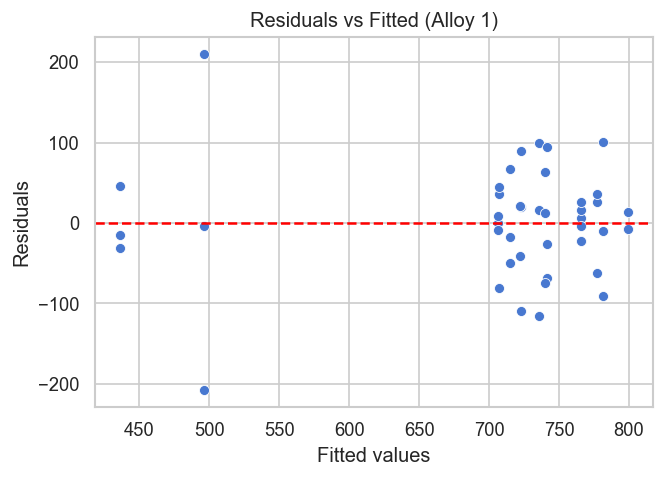

In [52]:
# --- Residual Diagnostics ---
print("\n--- Residual Diagnostics (Alloy 1) ---")
model = smf.ols("Response ~ C(Dentist) + C(Method) + C(Dentist):C(Method)", data=alloy1).fit()
residuals = model.resid
fitted = model.fittedvalues

# Residuals vs Fitted
plt.figure(figsize=(6,4))
sns.scatterplot(x=fitted, y=residuals)
plt.axhline(0, color="red", linestyle="--")
plt.xlabel("Fitted values")
plt.ylabel("Residuals")
plt.title("Residuals vs Fitted (Alloy 1)")
save_fig("p4_residual_diagnostics_alloy1.png")
plt.show()


  ✓ Saved: C:\Users\dsouh\OneDrive\Documents\PGP\Projectwork\2. Inferential Statistics - Multiple Case Studies\notebooks\..\images\p4_residual_histogram_alloy1.png


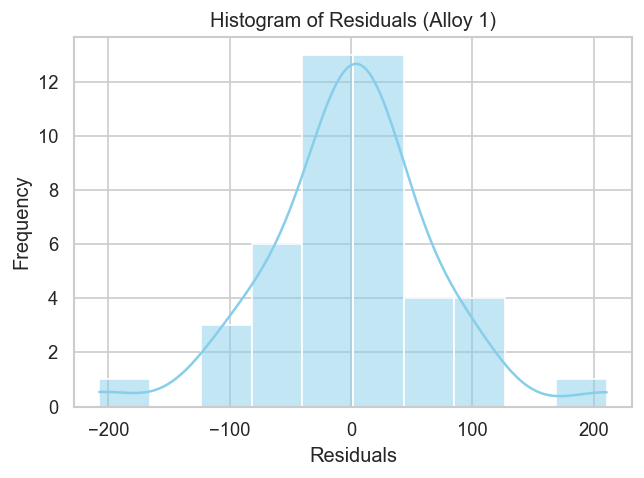

In [53]:
# Histogram of Residuals
plt.figure(figsize=(6,4))
sns.histplot(residuals, kde=True, bins=10, color="skyblue")
plt.title("Histogram of Residuals (Alloy 1)")
plt.xlabel("Residuals")
plt.ylabel("Frequency")
save_fig("p4_residual_histogram_alloy1.png")
plt.show()

  ✓ Saved: C:\Users\dsouh\OneDrive\Documents\PGP\Projectwork\2. Inferential Statistics - Multiple Case Studies\notebooks\..\images\p4_scale_location_alloy1.png


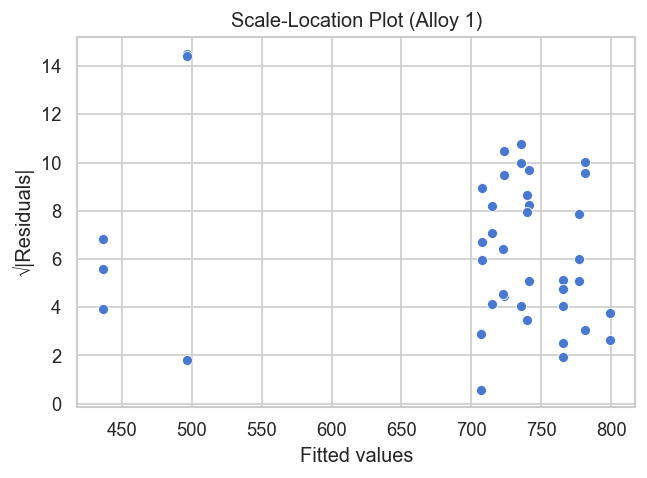

In [54]:
# Scale-Location Plot
plt.figure(figsize=(6,4))
sns.scatterplot(x=fitted, y=np.sqrt(np.abs(residuals)))
plt.xlabel("Fitted values")
plt.ylabel("√|Residuals|")
plt.title("Scale-Location Plot (Alloy 1)")
save_fig("p4_scale_location_alloy1.png")
plt.show()

In [55]:
# ================================
# One-Way ANOVA: Dentist Effect (Alloy 1)
# ================================

from scipy.stats import f_oneway

alloy1 = dental[dental["Alloy"] == 1]

# Group data by Dentist
dentist_groups = [grp["Response"].values for _, grp in alloy1.groupby("Dentist") if len(grp) > 1]

# Run One-Way ANOVA
if len(dentist_groups) > 1:
    F_stat, p_val = f_oneway(*dentist_groups)
    print(f"One-Way ANOVA (Dentist factor, Alloy 1): F = {F_stat:.3f}, p = {p_val:.4f}")
else:
    print("Not enough data for ANOVA across Dentists (Alloy 1).")


One-Way ANOVA (Dentist factor, Alloy 1): F = 1.977, p = 0.1166


In [56]:
# ================================
# Tukey's HSD Post-hoc Test
# ================================
if len(alloy1["Dentist"].unique()) > 2:
    tukey = pairwise_tukeyhsd(endog=alloy1["Response"], groups=alloy1["Dentist"], alpha=0.05)
    print("\nTukey HSD results (Dentist pairs, Alloy 1):")
    print(tukey.summary())
else:
    print("Not enough Dentist groups for Tukey’s HSD (Alloy 1).")


Tukey HSD results (Dentist pairs, Alloy 1):
  Multiple Comparison of Means - Tukey HSD, FWER=0.05   
group1 group2  meandiff p-adj    lower    upper   reject
--------------------------------------------------------
     1      2   11.3333 0.9996 -145.0423  167.709  False
     1      3  -32.3333 0.9757  -188.709 124.0423  False
     1      4  -68.7778 0.7189 -225.1535  87.5979  False
     1      5 -122.2222 0.1889 -278.5979  34.1535  False
     2      3  -43.6667 0.9298 -200.0423  112.709  False
     2      4  -80.1111 0.5916 -236.4868  76.2646  False
     2      5 -133.5556 0.1258 -289.9312  22.8201  False
     3      4  -36.4444 0.9626 -192.8201 119.9312  False
     3      5  -89.8889 0.4805 -246.2646  66.4868  False
     4      5  -53.4444 0.8643 -209.8201 102.9312  False
--------------------------------------------------------


In [57]:
# ================================
# One-Way ANOVA: Method Effect (Alloy 1)
# ================================

# Group data by Method
method_groups = [grp["Response"].values for _, grp in alloy1.groupby("Method") if len(grp) > 1]

# Run One-Way ANOVA
if len(method_groups) > 1:
    F_stat_m, p_val_m = f_oneway(*method_groups)
    print(f"One-Way ANOVA (Method factor, Alloy 1): F = {F_stat_m:.3f}, p = {p_val_m:.4f}")
else:
    print("Not enough data for ANOVA across Methods (Alloy 1).")


One-Way ANOVA (Method factor, Alloy 1): F = 6.263, p = 0.0042


In [58]:
# ================================
# Tukey's HSD Post-hoc Test (Methods)
# ================================
if len(alloy1["Method"].unique()) > 2:
    tukey_m = pairwise_tukeyhsd(endog=alloy1["Response"], groups=alloy1["Method"], alpha=0.05)
    print("\nTukey HSD results (Method pairs, Alloy 1):")
    print(tukey_m.summary())
else:
    print("Not enough Method groups for Tukey’s HSD (Alloy 1).")


Tukey HSD results (Method pairs, Alloy 1):
  Multiple Comparison of Means - Tukey HSD, FWER=0.05   
group1 group2  meandiff p-adj    lower    upper   reject
--------------------------------------------------------
     1      2   -6.1333  0.987  -102.714  90.4473  False
     1      3    -124.8 0.0085 -221.3807 -28.2193   True
     2      3 -118.6667 0.0128 -215.2473  -22.086   True
--------------------------------------------------------


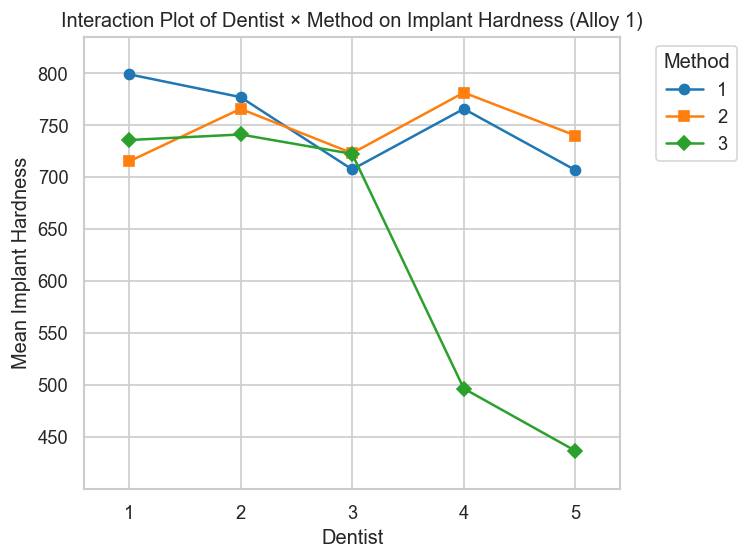

In [59]:
# ================================================
# Interaction Plot: Dentist × Method (Alloy 1)
# ================================================

from statsmodels.graphics.factorplots import interaction_plot

# Unique number of methods
n_methods = alloy1["Method"].nunique()

# Generate colors & markers automatically
colors = plt.cm.tab10.colors[:n_methods]   # up to 10 distinct colors
markers = ["o", "s", "D", "^", "v", "P", "X", "*"][:n_methods]  # enough markers

# Interaction plot
fig = interaction_plot(
    x=alloy1["Dentist"],
    trace=alloy1["Method"],
    response=alloy1["Response"],
    colors=colors,
    markers=markers,
    ms=6
)

plt.title("Interaction Plot of Dentist × Method on Implant Hardness (Alloy 1)")
plt.xlabel("Dentist")
plt.ylabel("Mean Implant Hardness")
plt.legend(title="Method", bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()
plt.show()

In [60]:
# ================================
# Two-Way ANOVA: Alloy 1
# ================================
alloy1 = dental[dental["Alloy"] == 1]

# Fit OLS model with interaction
from statsmodels.formula.api import ols

model = ols("Response ~ C(Dentist) * C(Method)", data=alloy1).fit()

# Get ANOVA table (Type II)
anova_table = sm.stats.anova_lm(model, typ=2)
print("\nTwo-Way ANOVA Results (Alloy 1):")
print(anova_table)

# Extract p-values
p_dentist = anova_table.loc["C(Dentist)", "PR(>F)"]
p_method = anova_table.loc["C(Method)", "PR(>F)"]
p_interaction = anova_table.loc["C(Dentist):C(Method)", "PR(>F)"]

# Print clean summary
print("\n--- P-Values Summary ---")
print(f"Dentist effect p-value     = {p_dentist:.4f}")
print(f"Method effect p-value      = {p_method:.4f}")
print(f"Interaction effect p-value = {p_interaction:.4f}")


Two-Way ANOVA Results (Alloy 1):
                             sum_sq    df          F    PR(>F)
C(Dentist)            106683.688889   4.0   3.899638  0.011484
C(Method)             148472.177778   2.0  10.854287  0.000284
C(Dentist):C(Method)  185941.377778   8.0   3.398383  0.006793
Residual              205180.000000  30.0        NaN       NaN

--- P-Values Summary ---
Dentist effect p-value     = 0.0115
Method effect p-value      = 0.0003
Interaction effect p-value = 0.0068



--- Tukey HSD: Dentist Effect (Alloy 1) ---


  Multiple Comparison of Means - Tukey HSD, FWER=0.05   
group1 group2  meandiff p-adj    lower    upper   reject
--------------------------------------------------------
     1      2   11.3333 0.9996 -145.0423  167.709  False
     1      3  -32.3333 0.9757  -188.709 124.0423  False
     1      4  -68.7778 0.7189 -225.1535  87.5979  False
     1      5 -122.2222 0.1889 -278.5979  34.1535  False
     2      3  -43.6667 0.9298 -200.0423  112.709  False
     2      4  -80.1111 0.5916 -236.4868  76.2646  False
     2      5 -133.5556 0.1258 -289.9312  22.8201  False
     3      4  -36.4444 0.9626 -192.8201 119.9312  False
     3      5  -89.8889 0.4805 -246.2646  66.4868  False
     4      5  -53.4444 0.8643 -209.8201 102.9312  False
--------------------------------------------------------


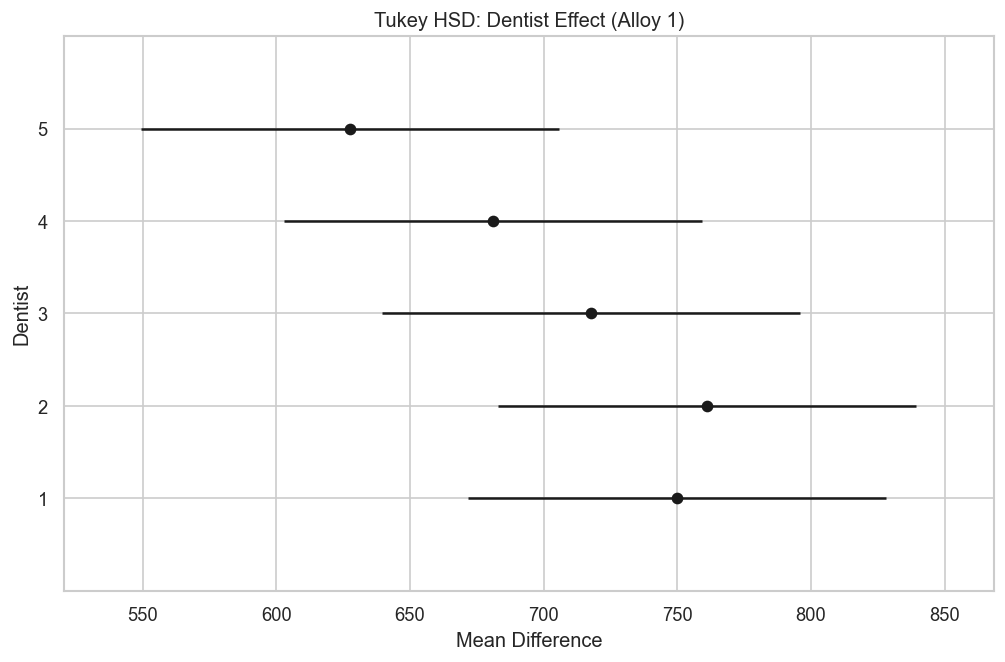


--- Tukey HSD: Method Effect (Alloy 1) ---


  Multiple Comparison of Means - Tukey HSD, FWER=0.05   
group1 group2  meandiff p-adj    lower    upper   reject
--------------------------------------------------------
     1      2   -6.1333  0.987  -102.714  90.4473  False
     1      3    -124.8 0.0085 -221.3807 -28.2193   True
     2      3 -118.6667 0.0128 -215.2473  -22.086   True
--------------------------------------------------------


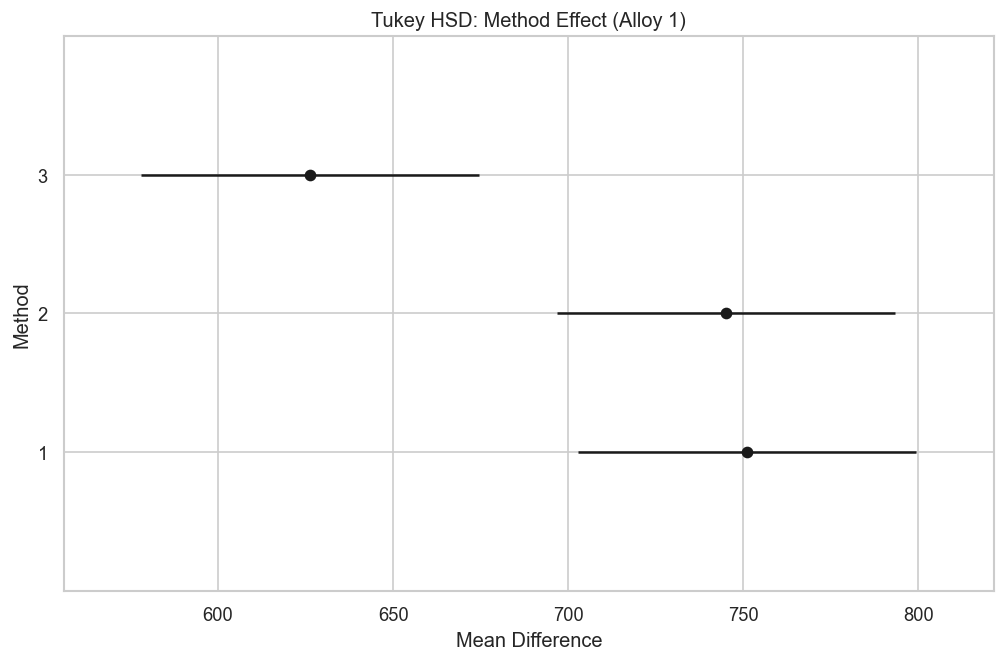


--- Tukey HSD: Dentist × Method Interaction (Alloy 1) ---


C:\Users\dsouh\AppData\Local\Temp\ipykernel_37928\2677800168.py:20: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  alloy1["Dentist_Method"] = alloy1["Dentist"].astype(str) + "_" + alloy1["Method"].astype(str)


   Multiple Comparison of Means - Tukey HSD, FWER=0.05   
group1 group2  meandiff p-adj    lower     upper   reject
---------------------------------------------------------
   1_1    1_2     -84.0 0.9933 -332.8283  164.8283  False
   1_1    1_3  -63.3333 0.9996 -312.1617   185.495  False
   1_1    2_1     -22.0    1.0 -270.8283  226.8283  False
   1_1    2_2  -33.3333    1.0 -282.1617   215.495  False
   1_1    2_3     -58.0 0.9999 -306.8283  190.8283  False
   1_1    3_1  -91.6667 0.9853  -340.495  157.1617  False
   1_1    3_2     -76.0 0.9975 -324.8283  172.8283  False
   1_1    3_3  -76.6667 0.9972  -325.495  172.1617  False
   1_1    4_1  -33.3333    1.0 -282.1617   215.495  False
   1_1    4_2  -17.6667    1.0  -266.495  231.1617  False
   1_1    4_3 -302.6667  0.007  -551.495  -53.8383   True
   1_1    5_1  -92.3333 0.9844 -341.1617   156.495  False
   1_1    5_2     -59.0 0.9998 -307.8283  189.8283  False
   1_1    5_3 -362.6667 0.0007  -611.495 -113.8383   True
   1_2    1_3 

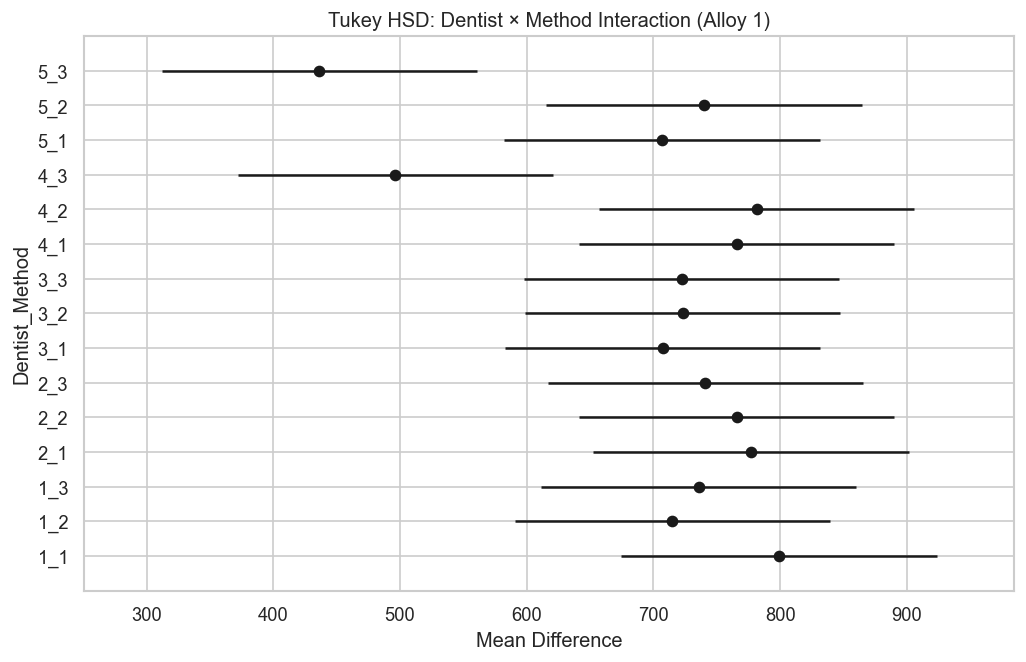

In [61]:
# --- Dentist Effect (Tukey HSD) ---
if alloy1["Dentist"].nunique() > 2:
    print("\n--- Tukey HSD: Dentist Effect (Alloy 1) ---")
    tukey_dentist = pairwise_tukeyhsd(alloy1["Response"], alloy1["Dentist"], alpha=0.05)
    print(tukey_dentist.summary())
    tukey_dentist.plot_simultaneous(comparison_name=None, xlabel="Mean Difference", ylabel="Dentist")
    plt.title("Tukey HSD: Dentist Effect (Alloy 1)")
    plt.show()

# --- Method Effect (Tukey HSD) ---
if alloy1["Method"].nunique() > 2:
    print("\n--- Tukey HSD: Method Effect (Alloy 1) ---")
    tukey_method = pairwise_tukeyhsd(alloy1["Response"], alloy1["Method"], alpha=0.05)
    print(tukey_method.summary())
    tukey_method.plot_simultaneous(comparison_name=None, xlabel="Mean Difference", ylabel="Method")
    plt.title("Tukey HSD: Method Effect (Alloy 1)")
    plt.show()

# --- Dentist × Method Interaction (Tukey HSD) ---
alloy1["Dentist_Method"] = alloy1["Dentist"].astype(str) + "_" + alloy1["Method"].astype(str)

if alloy1["Dentist_Method"].nunique() > 2:
    print("\n--- Tukey HSD: Dentist × Method Interaction (Alloy 1) ---")
    tukey_interaction = pairwise_tukeyhsd(alloy1["Response"], alloy1["Dentist_Method"], alpha=0.05)
    print(tukey_interaction.summary())
    tukey_interaction.plot_simultaneous(comparison_name=None, xlabel="Mean Difference", ylabel="Dentist_Method")
    plt.title("Tukey HSD: Dentist × Method Interaction (Alloy 1)")
    plt.show()


In [62]:
# ================================
# Descriptive Stats for Alloy 2
# ================================

# Subset Alloy 2 data
alloy2 = dental[dental['Alloy'] == 2]

# Group by Dentist and Method, calculate count, mean, std
desc_stats_alloy2 = alloy2.groupby(["Dentist", "Method"])["Response"].agg(
    n="count", mean="mean", sd="std"
).reset_index()

print("\n--- Descriptive Statistics: Alloy 2 by Dentist and Method ---")
display(desc_stats_alloy2)


--- Descriptive Statistics: Alloy 2 by Dentist and Method ---


,Dentist,Method,n,mean,sd
0,1,1,3,844.666667,58.106225
1,1,2,3,940.000000,152.561463
2,1,3,3,664.000000,158.974841
3,2,1,3,882.333333,24.501701
4,2,2,3,849.666667,73.921129
5,2,3,3,704.333333,27.061658
6,3,1,3,781.333333,69.060360
7,3,2,3,817.666667,32.959571
8,3,3,3,740.000000,74.706091
9,4,1,3,778.333333,123.070441


In [63]:
# ================================
# Assumption Checks - Alloy 2
# ================================

# Subset Alloy 2
alloy2 = dental[dental['Alloy'] == 2].copy()

# --- Shapiro-Wilk Test for Normality per Dentist × Method group ---
print("\n--- Shapiro-Wilk Test: Normality (Alloy 2) ---")
for (dent, meth), group in alloy2.groupby(["Dentist", "Method"]):
    if len(group["Response"]) > 3:  # Shapiro requires n > 3
        stat, p = shapiro(group["Response"])
        print(f"Dentist {dent}, Method {meth}: W={stat:.3f}, p={p:.4f}")
    else:
        print(f"Dentist {dent}, Method {meth}: Not enough data for Shapiro test.")


--- Shapiro-Wilk Test: Normality (Alloy 2) ---
Dentist 1, Method 1: Not enough data for Shapiro test.
Dentist 1, Method 2: Not enough data for Shapiro test.
Dentist 1, Method 3: Not enough data for Shapiro test.
Dentist 2, Method 1: Not enough data for Shapiro test.
Dentist 2, Method 2: Not enough data for Shapiro test.
Dentist 2, Method 3: Not enough data for Shapiro test.
Dentist 3, Method 1: Not enough data for Shapiro test.
Dentist 3, Method 2: Not enough data for Shapiro test.
Dentist 3, Method 3: Not enough data for Shapiro test.
Dentist 4, Method 1: Not enough data for Shapiro test.
Dentist 4, Method 2: Not enough data for Shapiro test.
Dentist 4, Method 3: Not enough data for Shapiro test.
Dentist 5, Method 1: Not enough data for Shapiro test.
Dentist 5, Method 2: Not enough data for Shapiro test.
Dentist 5, Method 3: Not enough data for Shapiro test.


  ✓ Saved: C:\Users\dsouh\OneDrive\Documents\PGP\Projectwork\2. Inferential Statistics - Multiple Case Studies\notebooks\..\images\p4_qq_plots_alloy2.png


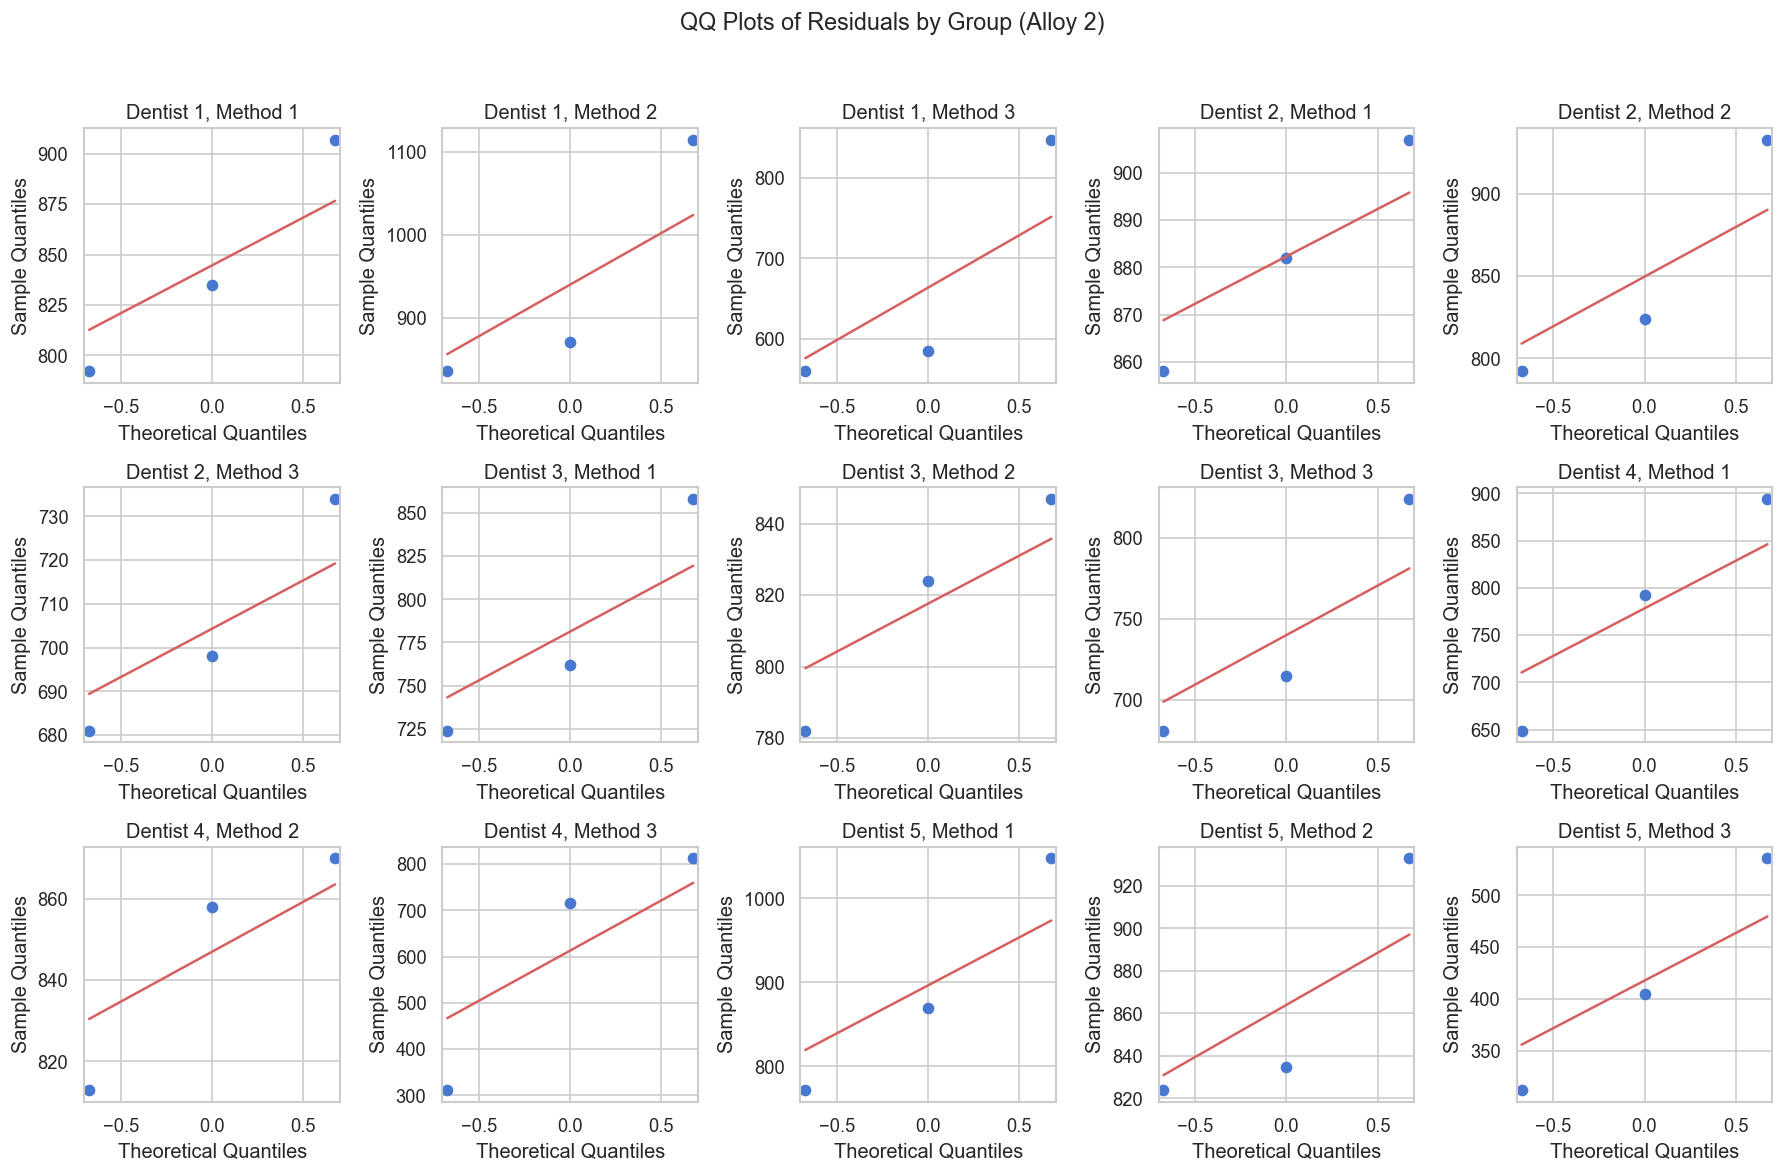

In [64]:
# --- QQ Plots for Normality per group ---
groups = alloy2.groupby(["Dentist", "Method"])
n_groups = len(groups)
ncols = 5
nrows = (n_groups // ncols) + 1

fig, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=(15, nrows*3))
axes = axes.flatten()

for ax, ((dent, meth), group) in zip(axes, groups):
    sm.qqplot(group["Response"], line='s', ax=ax)
    ax.set_title(f"Dentist {dent}, Method {meth}")

# Hide unused axes
for ax in axes[len(groups):]:
    ax.set_visible(False)

plt.suptitle("QQ Plots of Residuals by Group (Alloy 2)", y=1.02, fontsize=14)
plt.tight_layout()
save_fig("p4_qq_plots_alloy2.png")
plt.show()

In [65]:
# --- Levene's Test for Homogeneity of Variances ---
print("\n--- Levene's Test: Homogeneity of Variances (Alloy 2) ---")
groups_list = [g["Response"].values for _, g in groups]
stat, p = levene(*groups_list, center='median')
print(f"Levene’s Test stat={stat:.3f}, p={p:.4f}")


--- Levene's Test: Homogeneity of Variances (Alloy 2) ---
Levene’s Test stat=0.671, p=0.7832



--- Residual Diagnostics: Alloy 2 ---


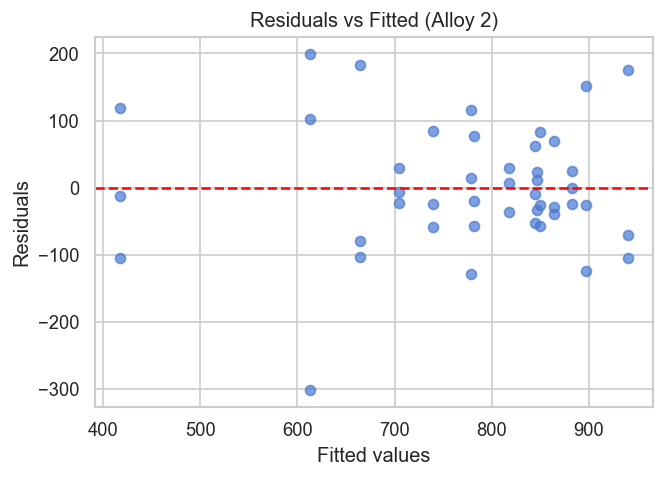

In [66]:
# --- Residual Diagnostics ---
print("\n--- Residual Diagnostics: Alloy 2 ---")
model_alloy2 = ols("Response ~ C(Dentist) * C(Method)", data=alloy2).fit()
residuals = model_alloy2.resid
fitted = model_alloy2.fittedvalues

# Residuals vs Fitted
plt.figure(figsize=(6,4))
plt.scatter(fitted, residuals, alpha=0.7)
plt.axhline(0, color="red", linestyle="--")
plt.xlabel("Fitted values")
plt.ylabel("Residuals")
plt.title("Residuals vs Fitted (Alloy 2)")
plt.show()

  ✓ Saved: C:\Users\dsouh\OneDrive\Documents\PGP\Projectwork\2. Inferential Statistics - Multiple Case Studies\notebooks\..\images\p4_residual_histogram_alloy2.png


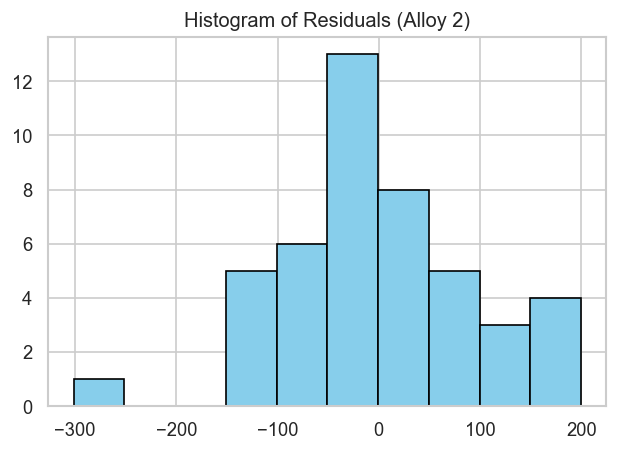

In [67]:
# Histogram of Residuals
plt.figure(figsize=(6,4))
plt.hist(residuals, bins=10, color="skyblue", edgecolor="black")
plt.title("Histogram of Residuals (Alloy 2)")
save_fig("p4_residual_histogram_alloy2.png")
plt.show()

  ✓ Saved: C:\Users\dsouh\OneDrive\Documents\PGP\Projectwork\2. Inferential Statistics - Multiple Case Studies\notebooks\..\images\p4_scale_location_alloy2.png


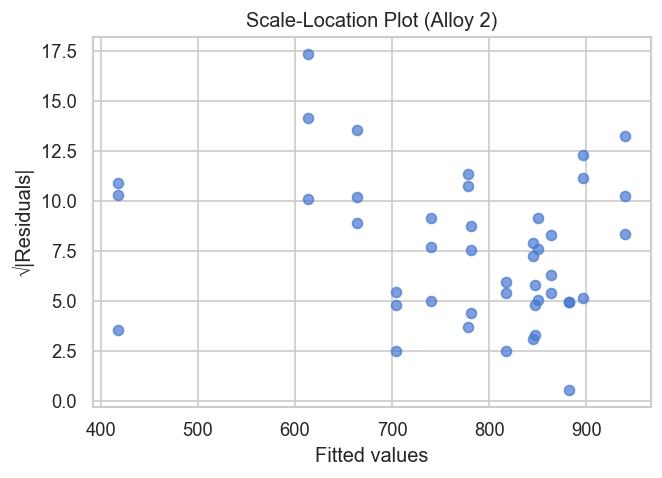

In [68]:
# Scale-Location Plot
plt.figure(figsize=(6,4))
plt.scatter(fitted, np.sqrt(np.abs(residuals)), alpha=0.7)
plt.xlabel("Fitted values")
plt.ylabel("√|Residuals|")
plt.title("Scale-Location Plot (Alloy 2)")
save_fig("p4_scale_location_alloy2.png")
plt.show()

In [69]:
# Subset Alloy 2 data
alloy2 = dental[dental['Alloy'] == 2]

# -------------------------------
# One-Way ANOVA: Dentist effect
# -------------------------------
anova_dentist = f_oneway(
    *[group["Response"].dropna() for _, group in alloy2.groupby("Dentist")]
)

print("\n--- One-Way ANOVA: Dentist effect on Alloy 2 ---")
print(f"F-statistic = {anova_dentist.statistic:.3f}, p-value = {anova_dentist.pvalue:.4f}")


--- One-Way ANOVA: Dentist effect on Alloy 2 ---
F-statistic = 0.525, p-value = 0.7180


In [70]:
# -------------------------------
# Tukey HSD: Dentist comparisons
# -------------------------------
if alloy2["Dentist"].nunique() > 1:
    tukey_dentist = pairwise_tukeyhsd(
        endog=alloy2["Response"],
        groups=alloy2["Dentist"],
        alpha=0.05
    )
    print("\n--- Tukey HSD: Dentist Pairwise Comparisons (Alloy 2) ---")
    print(tukey_dentist.summary())
else:
    print("Not enough groups for Tukey HSD test (Dentist, Alloy 2).")



--- Tukey HSD: Dentist Pairwise Comparisons (Alloy 2) ---
  Multiple Comparison of Means - Tukey HSD, FWER=0.05  
group1 group2 meandiff p-adj    lower    upper   reject
-------------------------------------------------------
     1      2  -4.1111    1.0 -225.5687 217.3465  False
     1      3 -36.5556 0.9895 -258.0131  184.902  False
     1      4    -70.0 0.8941 -291.4576 151.4576  False
     1      5 -90.1111 0.7724 -311.5687 131.3465  False
     2      3 -32.4444 0.9933  -253.902 189.0131  False
     2      4 -65.8889 0.9132 -287.3465 155.5687  False
     2      5    -86.0 0.8008 -307.4576 135.4576  False
     3      4 -33.4444 0.9925  -254.902 188.0131  False
     3      5 -53.5556 0.9574 -275.0131  167.902  False
     4      5 -20.1111  0.999 -241.5687 201.3465  False
-------------------------------------------------------


In [71]:
# Subset Alloy 2 data
alloy2 = dental[dental['Alloy'] == 2]

# -------------------------------
# One-Way ANOVA: Method effect
# -------------------------------
anova_method = f_oneway(
    *[group["Response"].dropna() for _, group in alloy2.groupby("Method")]
)

print("\n--- One-Way ANOVA: Method effect on Alloy 2 ---")
print(f"F-statistic = {anova_method.statistic:.3f}, p-value = {anova_method.pvalue:.4f}")



--- One-Way ANOVA: Method effect on Alloy 2 ---
F-statistic = 16.411, p-value = 0.0000


In [72]:
# -------------------------------
# Tukey HSD: Method comparisons
# -------------------------------
if alloy2["Method"].nunique() > 1:
    tukey_method = pairwise_tukeyhsd(
        endog=alloy2["Response"],
        groups=alloy2["Method"],
        alpha=0.05
    )
    print("\n--- Tukey HSD: Method Pairwise Comparisons (Alloy 2) ---")
    print(tukey_method.summary())
else:
    print("Not enough groups for Tukey HSD test (Method, Alloy 2).")


--- Tukey HSD: Method Pairwise Comparisons (Alloy 2) ---
  Multiple Comparison of Means - Tukey HSD, FWER=0.05   
group1 group2 meandiff p-adj    lower     upper   reject
--------------------------------------------------------
     1      2     27.0 0.8212  -82.4546  136.4546  False
     1      3   -208.8 0.0001 -318.2546  -99.3454   True
     2      3   -235.8    0.0 -345.2546 -126.3454   True
--------------------------------------------------------


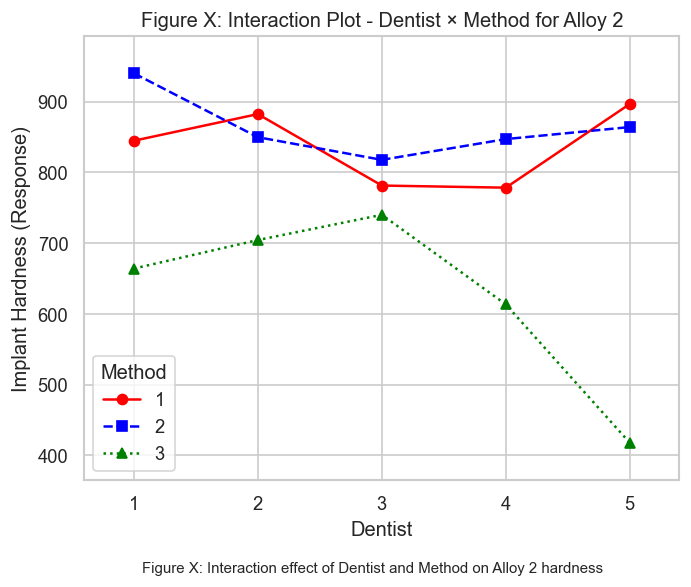

In [73]:

alloy2 = dental[dental['Alloy'] == 2].copy()

# ===============================
# Interaction Plot: Dentist × Method (Alloy 2)
# ===============================
fig = interaction_plot(
    x=alloy2["Dentist"].astype(str).values,
    trace=alloy2["Method"].astype(str).values,
    response=alloy2["Response"].values,
    colors=['red','blue','green'],
    markers=['o','s','^'],
    linestyles=['-','--',':']
)

plt.title("Figure X: Interaction Plot - Dentist × Method for Alloy 2")
plt.xlabel("Dentist")
plt.ylabel("Implant Hardness (Response)")
plt.legend(title="Method", loc="best")
plt.figtext(0.5, -0.05, "Figure X: Interaction effect of Dentist and Method on Alloy 2 hardness",
            wrap=True, ha='center', fontsize=9)
plt.show()

In [74]:
# ===============================
# Two-Way ANOVA
# ===============================
model_alloy2 = ols("Response ~ C(Dentist) * C(Method)", data=alloy2).fit()
anova_table_alloy2 = sm.stats.anova_lm(model_alloy2, typ=2)

print("\n--- Two-Way ANOVA Results: Alloy 2 ---")
print(anova_table_alloy2)


--- Two-Way ANOVA Results: Alloy 2 ---
                             sum_sq    df          F    PR(>F)
C(Dentist)             56797.911111   4.0   1.106152  0.371833
C(Method)             499640.400000   2.0  19.461218  0.000004
C(Dentist):C(Method)  197459.822222   8.0   1.922787  0.093234
Residual              385104.666667  30.0        NaN       NaN


In [75]:
# ===============================
# Post-hoc Tukey HSD
# ===============================

# If Dentist main effect significant
print("\n--- Tukey HSD: Dentist (Alloy 2) ---")
if anova_table_alloy2.loc["C(Dentist)", "PR(>F)"] < 0.05:
    tukey_dentist_alloy2 = pairwise_tukeyhsd(alloy2["Response"], alloy2["Dentist"], alpha=0.05)
    print(tukey_dentist_alloy2.summary())
else:
    print("No significant Dentist effect detected (skip Tukey).")

# If Method main effect significant
print("\n--- Tukey HSD: Method (Alloy 2) ---")
if anova_table_alloy2.loc["C(Method)", "PR(>F)"] < 0.05:
    tukey_method_alloy2 = pairwise_tukeyhsd(alloy2["Response"], alloy2["Method"], alpha=0.05)
    print(tukey_method_alloy2.summary())
else:
    print("No significant Method effect detected (skip Tukey).")

# If Interaction significant
print("\n--- Tukey HSD: Dentist × Method Interaction (Alloy 2) ---")
if anova_table_alloy2.loc["C(Dentist):C(Method)", "PR(>F)"] < 0.05:
    alloy2["Dentist_Method"] = alloy2["Dentist"].astype(str) + "_" + alloy2["Method"].astype(str)
    tukey_interaction_alloy2 = pairwise_tukeyhsd(alloy2["Response"], alloy2["Dentist_Method"], alpha=0.05)
    print(tukey_interaction_alloy2.summary())
else:
    print("No significant Interaction effect detected (skip Tukey).")



--- Tukey HSD: Dentist (Alloy 2) ---
No significant Dentist effect detected (skip Tukey).

--- Tukey HSD: Method (Alloy 2) ---
  Multiple Comparison of Means - Tukey HSD, FWER=0.05   
group1 group2 meandiff p-adj    lower     upper   reject
--------------------------------------------------------
     1      2     27.0 0.8212  -82.4546  136.4546  False
     1      3   -208.8 0.0001 -318.2546  -99.3454   True
     2      3   -235.8    0.0 -345.2546 -126.3454   True
--------------------------------------------------------

--- Tukey HSD: Dentist × Method Interaction (Alloy 2) ---
No significant Interaction effect detected (skip Tukey).


In [76]:
from statsmodels.stats.weightstats import CompareMeans, DescrStatsW

# Subset Alloy 1 data
alloy1 = dental[dental['Alloy'] == 1].copy()
alloy1["Dentist_Method"] = alloy1["Dentist"].astype(str) + "_" + alloy1["Method"].astype(str)

# Get group descriptive statistics
group_stats = alloy1.groupby("Dentist_Method")["Response"].agg(["mean","std","count"])
print("\n--- Descriptive Stats by Dentist × Method (Alloy 1) ---")
print(group_stats)

# Compute pairwise effect sizes (Cohen’s d) with 95% CI
results = []
groups = alloy1["Dentist_Method"].unique()

for i in range(len(groups)):
    for j in range(i+1, len(groups)):
        g1 = alloy1.loc[alloy1["Dentist_Method"] == groups[i], "Response"].dropna()
        g2 = alloy1.loc[alloy1["Dentist_Method"] == groups[j], "Response"].dropna()

        if len(g1) > 1 and len(g2) > 1:
            # Compare means using statsmodels
            cm = CompareMeans(DescrStatsW(g1), DescrStatsW(g2))
            ci_low, ci_high = cm.tconfint_diff(usevar='unequal')
            effsize = (g1.mean() - g2.mean()) / ( ( (g1.std()**2 + g2.std()**2) / 2 )**0.5 )

            results.append({
                "Group1": groups[i],
                "Group2": groups[j],
                "MeanDiff": g1.mean() - g2.mean(),
                "Cohen_d": effsize,
                "95%CI_Lower": ci_low,
                "95%CI_Upper": ci_high
            })

effect_table = pd.DataFrame(results)
print("\n--- Effect Sizes and Confidence Intervals (Dentist × Method, Alloy 1) ---")
print(effect_table.round(3))



--- Descriptive Stats by Dentist × Method (Alloy 1) ---
                      mean         std  count
Dentist_Method                               
1_1             799.000000   12.124356      3
1_2             715.000000   60.324125      3
1_3             735.666667  108.426626      3
2_1             777.000000   53.925875      3
2_2             765.666667   20.256686      3
2_3             741.000000   84.071398      3
3_1             707.333333   69.716091      3
3_2             723.000000  101.488916      3
3_3             722.333333   35.795717      3
4_1             765.666667   24.704925      3
4_2             781.333333   96.339677      3
4_3             496.333333  209.019935      3
5_1             706.666667    8.504901      3
5_2             740.000000   69.778220      3
5_3             436.333333   41.198705      3



--- Effect Sizes and Confidence Intervals (Dentist × Method, Alloy 1) ---
    Group1 Group2  MeanDiff  Cohen_d  95%CI_Lower  95%CI_Upper
0      1_1    1_2    84.000    1.931      -58.421      226.421
1      1_1    1_3    63.333    0.821     -201.454      328.121
2      1_1    2_1    22.000    0.563     -103.927      147.927
3      1_1    2_2    33.333    1.997       -8.086       74.753
4      1_1    2_3    58.000    0.966     -145.136      261.136
..     ...    ...       ...      ...          ...          ...
100    4_3    5_2  -243.667   -1.564     -706.509      219.175
101    4_3    5_3    60.000    0.398     -434.337      554.337
102    5_1    5_2   -33.333   -0.671     -203.215      136.548
103    5_1    5_3   270.333    9.088      173.304      367.362
104    5_2    5_3   303.667    5.300      160.902      446.432

[105 rows x 6 columns]
